# 🔧 Day 25: GPU FinOps & Cost Optimization - Hands-on Lab

This notebook connects to a local Docker Compose cluster (via ngrok/cloudflared tunnel) to demonstrate:
1. **GPU Cluster Monitoring** - Real-time GPU metrics
2. **Cost Tracking (OpenCost-like)** - Per-node cost allocation & waste analysis
3. **Spot Instance Management** - Bidding, preemption, savings
4. **Autoscaling (KEDA-like)** - Policy-based GPU scaling
5. **Budget Management & Forecasting** - Alerts, burn rate

## Prerequisites
- Docker Compose running locally with the GPU FinOps Lab services
- Tunnel exposed via ngrok or cloudflared (free tier)

In [11]:
# Cell 1: Setup
!pip install -q requests pandas matplotlib plotly

import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import json
from IPython.display import display, HTML, clear_output

In [12]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Vũ Văn Huân"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600348"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%);
                color: white; padding: 15px; border-radius: 10px;
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} |
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [13]:
# Cell 2: Configure Gateway URL
display_student_header()
# Replace with your ngrok/cloudflared URL after running the tunnel
GATEWAY_URL = "https://geographical-morning-needed-abroad.trycloudflare.com"  # <-- CHANGE THIS

# Test connection
try:
    r = requests.get(f"{GATEWAY_URL}/", timeout=10)
    print("✅ Connected to GPU FinOps Lab Gateway")
    print(json.dumps(r.json(), indent=2))
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("Make sure Docker Compose is running and tunnel is active")

✅ Connected to GPU FinOps Lab Gateway
{
  "service": "GPU FinOps Lab Gateway",
  "endpoints": {
    "cluster": "/cluster/*",
    "billing": "/billing/*",
    "spot": "/spot/*",
    "autoscaler": "/autoscaler/*",
    "cost": "/cost/*"
  }
}


---
## Part 1: GPU Cluster Monitoring
Observe the mock GPU cluster state — nodes, utilization, memory, power draw.

In [14]:
# Cell 3: View Cluster Nodes
display_student_header()
nodes = requests.get(f"{GATEWAY_URL}/cluster/nodes").json()

print(f"📊 Cluster has {len(nodes)} nodes")
print("=" * 60)

for node_id, gpus in nodes.items():
    print(f"\n🖥️  {node_id}:")
    for gpu in gpus:
        status_icon = "🟢" if gpu['status'] == 'idle' else "🔴"
        print(f"   GPU {gpu['gpu_id']} [{gpu['gpu_type']}] {status_icon} "
              f"Util: {gpu['utilization']:.1f}% | "
              f"Mem: {gpu['memory_used_gb']:.1f}/{gpu['memory_total_gb']}GB | "
              f"Power: {gpu['power_draw_watts']:.0f}W | "
              f"Temp: {gpu['temperature_c']:.0f}°C")

📊 Cluster has 4 nodes

🖥️  node-00:
   GPU 0 [T4] 🟢 Util: 10.1% | Mem: 1.9/16.0GB | Power: 34W | Temp: 39°C
   GPU 1 [T4] 🟢 Util: 5.9% | Mem: 0.7/16.0GB | Power: 31W | Temp: 33°C

🖥️  node-01:
   GPU 0 [A100] 🟢 Util: 8.2% | Mem: 1.6/80.0GB | Power: 31W | Temp: 31°C
   GPU 1 [A100] 🟢 Util: 6.5% | Mem: 1.4/80.0GB | Power: 50W | Temp: 42°C

🖥️  node-02:
   GPU 0 [V100] 🟢 Util: 3.9% | Mem: 0.8/32.0GB | Power: 44W | Temp: 32°C
   GPU 1 [V100] 🟢 Util: 6.2% | Mem: 0.5/32.0GB | Power: 20W | Temp: 40°C

🖥️  node-03:
   GPU 0 [T4] 🟢 Util: 14.7% | Mem: 1.4/16.0GB | Power: 38W | Temp: 36°C
   GPU 1 [T4] 🟢 Util: 5.3% | Mem: 0.9/16.0GB | Power: 43W | Temp: 37°C


In [15]:
# Cell 4: Cluster Metrics Summary
display_student_header()
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()

print("📈 Cluster Metrics")
print("=" * 40)
print(f"Total GPUs:          {metrics['total_gpus']}")
print(f"Busy GPUs:           {metrics['busy_gpus']}")
print(f"Idle GPUs:           {metrics['idle_gpus']}")
print(f"Avg Utilization:     {metrics['avg_utilization']:.1f}%")
print(f"Memory Used:         {metrics['total_memory_used_gb']:.1f} GB")
print(f"Memory Capacity:     {metrics['total_memory_capacity_gb']:.1f} GB")
print(f"Total Power Draw:    {metrics['total_power_draw_watts']:.0f} W")
print(f"Node Count:          {metrics['node_count']}")

📈 Cluster Metrics
Total GPUs:          8
Busy GPUs:           0
Idle GPUs:           8
Avg Utilization:     7.6%
Memory Used:         9.2 GB
Memory Capacity:     288.0 GB
Total Power Draw:    291 W
Node Count:          4


---
## Part 2: Workload Submission & Cost Tracking
Submit GPU workloads and track their costs in real-time.

In [16]:
# Cell 5: Submit multiple workloads
display_student_header()
workloads = [
    {"workload_id": "train-resnet-001", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 300},
    {"workload_id": "train-bert-002", "gpu_type_preferred": "A100", "gpu_count": 1, "duration_seconds": 600},
    {"workload_id": "inference-api-003", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 120},
    {"workload_id": "train-llm-004", "gpu_type_preferred": "A100", "gpu_count": 2, "duration_seconds": 900},
]

print("🚀 Submitting workloads...")
for wl in workloads:
    r = requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json=wl)
    result = r.json()
    print(f"   {wl['workload_id']}: {result['status']} → {result.get('assigned', 'queued')}")

# Check cluster state after submission
print("\n📊 Updated metrics:")
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   Busy GPUs: {metrics['busy_gpus']}/{metrics['total_gpus']} | Utilization: {metrics['avg_utilization']:.1f}%")

🚀 Submitting workloads...
   train-resnet-001: running → [{'node_id': 'node-00', 'gpu_id': 0}]
   train-bert-002: running → [{'node_id': 'node-01', 'gpu_id': 0}]
   inference-api-003: running → [{'node_id': 'node-00', 'gpu_id': 1}]
   train-llm-004: running → [{'node_id': 'node-01', 'gpu_id': 1}, {'node_id': 'node-02', 'gpu_id': 0}]

📊 Updated metrics:
   Busy GPUs: 5/8 | Utilization: 47.1%


In [17]:
# Cell 6: Record billing for workloads
display_student_header()
billing_events = [
    {"workload_id": "train-resnet-001", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 300, "is_spot": False},
    {"workload_id": "train-bert-002", "gpu_type": "A100", "gpu_count": 1, "duration_seconds": 600, "is_spot": False},
    {"workload_id": "inference-api-003", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 120, "is_spot": True},
    {"workload_id": "train-llm-004", "gpu_type": "A100", "gpu_count": 2, "duration_seconds": 900, "is_spot": True},
]

print("💰 Recording billing events...")
for event in billing_events:
    r = requests.post(f"{GATEWAY_URL}/billing/record", json=event)
    result = r.json()
    spot_label = "[SPOT]" if event['is_spot'] else "[ON-DEMAND]"
    print(f"   {event['workload_id']} {spot_label}: ${result['total_cost_usd']:.4f} "
          f"(saved ${result['savings_usd']:.4f})")

# Get billing summary
print("\n📋 Billing Summary:")
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total Cost:     ${summary['total_cost_usd']:.4f}")
print(f"   Total Savings:  ${summary['total_savings_usd']:.4f}")
print(f"   Budget Used:    {summary['budget_utilization_pct']:.1f}%")
print(f"   Alert Status:   {summary['alert']}")

💰 Recording billing events...
   train-resnet-001 [ON-DEMAND]: $0.0292 (saved $0.0000)
   train-bert-002 [ON-DEMAND]: $0.6117 (saved $0.0000)
   inference-api-003 [SPOT]: $0.0035 (saved $0.0082)
   train-llm-004 [SPOT]: $0.5505 (saved $1.2845)

📋 Billing Summary:
   Total Cost:     $1.1949
   Total Savings:  $1.2927
   Budget Used:    1.2%
   Alert Status:   OK


---
## Part 3: Spot Instance Management
Demonstrate spot bidding, preemption handling, and cost savings.

In [18]:
# Cell 7: Check spot pricing
display_student_header()
spot_pricing = requests.get(f"{GATEWAY_URL}/spot/pricing").json()

print("💹 Current Spot Pricing")
print("=" * 60)
print(f"{'GPU Type':<10} {'On-Demand':<12} {'Spot Price':<12} {'Discount':<10} {'Availability'}")
print("-" * 60)
for gpu, info in spot_pricing.items():
    print(f"{gpu:<10} ${info['on_demand_price']:<10.2f} ${info['current_spot_price']:<10.4f} "
          f"{info['discount_pct']:<8.1f}% {info['availability']}")

💹 Current Spot Pricing
GPU Type   On-Demand    Spot Price   Discount   Availability
------------------------------------------------------------
T4         $0.35       $0.2662     24.0    % low
A100       $3.67       $2.8676     21.9    % high
V100       $2.48       $1.7464     29.6    % medium


In [19]:
# Cell 8: Request spot instances
display_student_header()
spot_requests = [
    {"instance_id": "spot-t4-001", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": "batch-job-1"},
    {"instance_id": "spot-t4-002", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.12, "workload_id": "batch-job-2"},
    {"instance_id": "spot-a100-001", "gpu_type": "A100", "gpu_count": 1, "max_price_per_hour": 1.50, "workload_id": "training-3"},
]

print("🎯 Requesting Spot Instances...")
for req in spot_requests:
    r = requests.post(f"{GATEWAY_URL}/spot/request", json=req)
    result = r.json()
    status_icon = "✅" if result['status'] == 'granted' else "❌"
    print(f"   {status_icon} {req['instance_id']} ({req['gpu_type']}): {result['status']}")
    if result['status'] == 'rejected':
        print(f"      Reason: {result.get('reason', 'N/A')}")

🎯 Requesting Spot Instances...
   ✅ spot-t4-001 (T4): granted
   ✅ spot-t4-002 (T4): granted
   ✅ spot-a100-001 (A100): granted


In [20]:
# Cell 9: Simulate spot preemption
display_student_header()
print("⚡ Simulating spot preemption event...")
preemption = requests.post(f"{GATEWAY_URL}/spot/simulate-preemption").json()

print(f"\n   Preempted instances: {preemption['preempted_count']}")
print(f"   Still active: {preemption['total_active']}")

if preemption['preempted_instances']:
    print("\n   ⚠️  Preempted:")
    for p in preemption['preempted_instances']:
        print(f"      - {p['instance_id']} (ran for {p['runtime_seconds']:.0f}s, "
              f"{p['notice_seconds']}s warning)")

# Savings report
print("\n💰 Spot Savings Report:")
savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot cost:        ${savings['total_spot_cost']:.4f}")
print(f"   On-demand equiv:  ${savings['on_demand_equivalent']:.4f}")
print(f"   Total saved:      ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

⚡ Simulating spot preemption event...

   Preempted instances: 0
   Still active: 3

💰 Spot Savings Report:
   Spot cost:        $0.0004
   On-demand equiv:  $0.0012
   Total saved:      $0.0009 (70.0%)


---
## Part 4: Autoscaling (KEDA-like)
Configure and trigger GPU autoscaling based on utilization thresholds.

In [21]:
# Cell 10: View and update autoscaling policy
display_student_header()
policy = requests.get(f"{GATEWAY_URL}/autoscaler/policy").json()
print("📜 Current Autoscaling Policy:")
for k, v in policy.items():
    print(f"   {k}: {v}")

# Update policy - more aggressive scaling
new_policy = {
    "scale_up_threshold": 70,
    "scale_down_threshold": 25,
    "cooldown_seconds": 30,
    "max_nodes": 10,
    "min_nodes": 2,
    "preferred_gpu_type": "T4",
    "cost_aware": True
}

print("\n🔄 Updating policy...")
updated = requests.post(f"{GATEWAY_URL}/autoscaler/policy", json=new_policy).json()
print("   ✅ Policy updated")

📜 Current Autoscaling Policy:
   scale_up_threshold: 80.0
   scale_down_threshold: 20.0
   cooldown_seconds: 60
   max_nodes: 8
   min_nodes: 1
   preferred_gpu_type: T4
   cost_aware: True

🔄 Updating policy...
   ✅ Policy updated


In [22]:
# Cell 11: Trigger autoscaler evaluation
display_student_header()
print("🔄 Evaluating autoscaling decision...")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()

action_icons = {"scale_up": "⬆️", "scale_down": "⬇️", "no_action": "➡️"}
print(f"\n   {action_icons.get(decision['action'], '❓')} Action: {decision['action'].upper()}")
print(f"   Reason: {decision['reason']}")
print(f"   Current utilization: {decision['current_utilization']:.1f}%")
print(f"   Nodes: {decision['node_count']} → {decision['target_node_count']}")

# Run multiple evaluations to show scaling behavior
print("\n📊 Running 5 evaluation cycles...")
for i in range(5):
    time.sleep(2)
    d = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
    print(f"   Cycle {i+1}: {d['action']:<12} | Util: {d['current_utilization']:.1f}% | Nodes: {d['node_count']}→{d['target_node_count']}")

🔄 Evaluating autoscaling decision...

   ➡️ Action: NO_ACTION
   Reason: Utilization 47.1% within thresholds [25.0-70.0%]
   Current utilization: 47.1%
   Nodes: 4 → 4

📊 Running 5 evaluation cycles...
   Cycle 1: no_action    | Util: 47.1% | Nodes: 4→4
   Cycle 2: no_action    | Util: 47.1% | Nodes: 4→4
   Cycle 3: no_action    | Util: 47.1% | Nodes: 4→4
   Cycle 4: no_action    | Util: 47.1% | Nodes: 4→4
   Cycle 5: no_action    | Util: 47.1% | Nodes: 4→4


---
## Part 5: Cost Analysis & Optimization (OpenCost-like)
Analyze cost allocation, identify waste, and get recommendations.

In [23]:
# Cell 12: Take cost snapshots
display_student_header()
print("📸 Taking cost snapshots...")
snapshots = []
for i in range(5):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    snapshots.append(snap)
    print(f"   Snapshot {i+1}: Total=${snap['total_cost_usd']:.6f} | "
          f"Idle=${snap['total_idle_cost_usd']:.6f} | "
          f"Waste={snap['waste_pct']:.1f}%")
    time.sleep(1)

📸 Taking cost snapshots...
   Snapshot 1: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 2: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 3: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 4: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 5: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%


In [24]:
# Cell 13: Waste Report
display_student_header()
waste = requests.get(f"{GATEWAY_URL}/cost/waste-report").json()

print("🗑️  WASTE ANALYSIS REPORT")
print("=" * 50)
print(f"   Average Waste:          {waste.get('avg_waste_pct', 0):.1f}%")
print(f"   Total Idle Cost:        ${waste.get('total_idle_cost_usd', 0):.6f}")
print(f"   Total Cost:             ${waste.get('total_cost_usd', 0):.6f}")
print(f"   Potential Monthly Save:  ${waste.get('potential_monthly_savings', 0):.2f}")
print(f"   Severity:               {waste.get('severity', 'N/A')}")

🗑️  WASTE ANALYSIS REPORT
   Average Waste:          23.2%
   Total Idle Cost:        $0.044165
   Total Cost:             $0.190280
   Potential Monthly Save:  $2289.51
   Severity:               LOW


In [25]:
# Cell 14: Get Optimization Recommendations
display_student_header()
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()

print("💡 COST OPTIMIZATION RECOMMENDATIONS")
print("=" * 60)
for i, rec in enumerate(recs, 1):
    priority_icons = {"HIGH": "🔴", "MEDIUM": "🟡", "LOW": "🟢"}
    icon = priority_icons.get(rec['priority'], '⚪')
    print(f"\n{i}. {icon} [{rec['priority']}] {rec['type']}")
    print(f"   {rec['description']}")
    print(f"   Estimated savings: {rec['estimated_savings_pct']:.1f}%")

💡 COST OPTIMIZATION RECOMMENDATIONS

1. 🟡 [MEDIUM] USE_SPOT
   Switch fault-tolerant workloads to spot instances for 60-70% savings.
   Estimated savings: 65.0%

2. 🟢 [LOW] SCHEDULING
   Schedule non-urgent training jobs during off-peak hours for lower spot prices.
   Estimated savings: 20.0%


In [26]:
# Cell 15: Full Dashboard View
display_student_header()
dashboard = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()

print("📊 GPU FinOps DASHBOARD")
print("=" * 60)

cm = dashboard.get('cluster_metrics', {})
print(f"\n🖥️  CLUSTER: {cm.get('total_gpus', 0)} GPUs across {cm.get('node_count', 0)} nodes")
print(f"   Utilization: {cm.get('avg_utilization', 0):.1f}% | Busy: {cm.get('busy_gpus', 0)} | Idle: {cm.get('idle_gpus', 0)}")

bs = dashboard.get('billing_summary', {})
print(f"\n💰 BILLING: ${bs.get('total_cost_usd', 0):.4f} / ${bs.get('budget_usd', 0):.2f} budget")
print(f"   Alert: {bs.get('alert', 'N/A')} | Savings: ${bs.get('total_savings_usd', 0):.4f}")

ss = dashboard.get('spot_savings', {})
print(f"\n🎯 SPOT: Saved ${ss.get('total_savings', 0):.4f} ({ss.get('savings_pct', 0):.1f}%)")

wa = dashboard.get('waste_analysis', {})
if wa:
    print(f"\n🗑️  WASTE: {wa.get('avg_waste_pct', 0):.1f}% | Severity: {wa.get('severity', 'N/A')}")

📊 GPU FinOps DASHBOARD

🖥️  CLUSTER: 8 GPUs across 4 nodes
   Utilization: 47.1% | Busy: 5 | Idle: 3

💰 BILLING: $1.1949 / $100.00 budget
   Alert: OK | Savings: $1.2927

🎯 SPOT: Saved $0.0202 (70.0%)

🗑️  WASTE: 23.2% | Severity: LOW


---
## Part 6: Visualization
Create charts for cost breakdown and utilization trends.

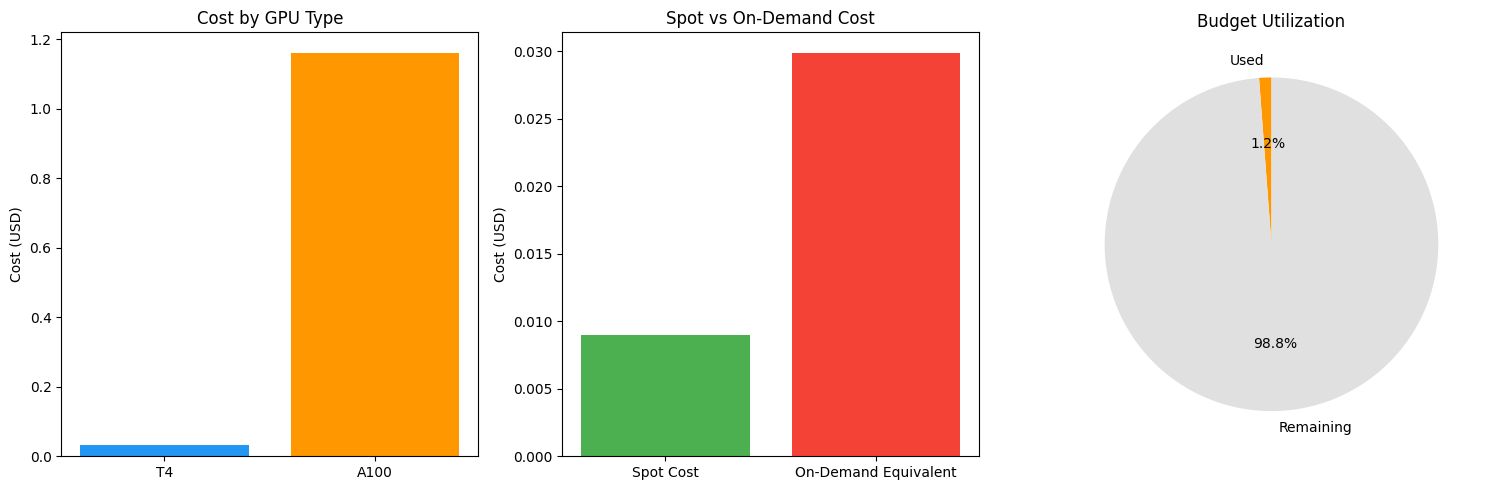

📊 Chart saved as finops_cost_breakdown.png


In [27]:
# Cell 16: Cost Breakdown Visualization
display_student_header()
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Cost by GPU type
cost_by_type = summary.get('cost_by_gpu_type', {})
if cost_by_type:
    types = list(cost_by_type.keys())
    costs = [cost_by_type[t]['cost'] for t in types]
    axes[0].bar(types, costs, color=['#2196F3', '#FF9800', '#4CAF50'])
    axes[0].set_title('Cost by GPU Type')
    axes[0].set_ylabel('Cost (USD)')

# Chart 2: Spot vs On-Demand
spot_data = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
labels = ['Spot Cost', 'On-Demand Equivalent']
values = [spot_data.get('total_spot_cost', 0), spot_data.get('on_demand_equivalent', 0)]
axes[1].bar(labels, values, color=['#4CAF50', '#F44336'])
axes[1].set_title('Spot vs On-Demand Cost')
axes[1].set_ylabel('Cost (USD)')

# Chart 3: Budget utilization
budget_used = summary.get('budget_utilization_pct', 0)
axes[2].pie([budget_used, 100-budget_used], labels=['Used', 'Remaining'],
            colors=['#FF9800', '#E0E0E0'], autopct='%1.1f%%', startangle=90)
axes[2].set_title('Budget Utilization')

plt.tight_layout()
plt.savefig('finops_cost_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved as finops_cost_breakdown.png")

📈 Collecting time-series data (10 snapshots)...


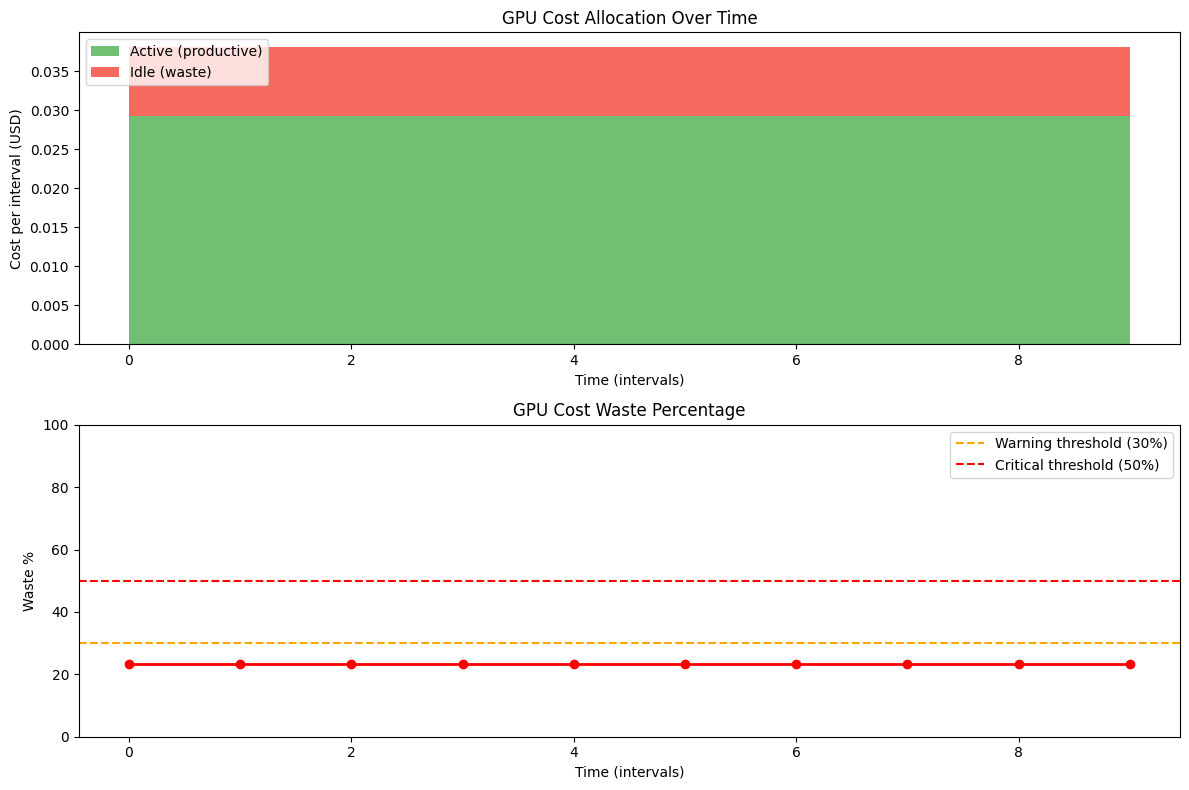

In [28]:
# Cell 17: Time-series cost tracking
display_student_header()
print("📈 Collecting time-series data (10 snapshots)...")
ts_data = []
for i in range(10):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    ts_data.append({
        'time': i,
        'total_cost': snap['total_cost_usd'],
        'idle_cost': snap['total_idle_cost_usd'],
        'active_cost': snap['total_active_cost_usd'],
        'waste_pct': snap['waste_pct'],
    })
    time.sleep(1)

df = pd.DataFrame(ts_data)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Cost over time
ax1.stackplot(df['time'], df['active_cost'], df['idle_cost'],
              labels=['Active (productive)', 'Idle (waste)'],
              colors=['#4CAF50', '#F44336'], alpha=0.8)
ax1.set_xlabel('Time (intervals)')
ax1.set_ylabel('Cost per interval (USD)')
ax1.set_title('GPU Cost Allocation Over Time')
ax1.legend(loc='upper left')

# Waste percentage
ax2.plot(df['time'], df['waste_pct'], 'r-o', linewidth=2)
ax2.axhline(y=30, color='orange', linestyle='--', label='Warning threshold (30%)')
ax2.axhline(y=50, color='red', linestyle='--', label='Critical threshold (50%)')
ax2.set_xlabel('Time (intervals)')
ax2.set_ylabel('Waste %')
ax2.set_title('GPU Cost Waste Percentage')
ax2.legend()
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('finops_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 7: Complete FinOps Workflow
Run a full cycle: submit workloads → monitor → detect waste → autoscale → optimize cost.

In [29]:
# Cell 18: Full FinOps Optimization Workflow
display_student_header()
print("🔄 FULL FINOPS OPTIMIZATION WORKFLOW")
print("=" * 60)

# Step 1: Check initial state
print("\n1️⃣  Initial cluster state:")
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   GPUs: {m['total_gpus']} | Util: {m['avg_utilization']:.1f}% | Idle: {m['idle_gpus']}")

# Step 2: Submit heavy workloads to increase utilization
print("\n2️⃣  Submitting heavy workloads...")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 600
    })
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   After load: Util: {m['avg_utilization']:.1f}% | Busy: {m['busy_gpus']}/{m['total_gpus']}")

# Step 3: Autoscaler evaluates
print("\n3️⃣  Autoscaler evaluation:")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
print(f"   Decision: {decision['action']} - {decision['reason']}")

# Step 4: Cost snapshot
print("\n4️⃣  Cost analysis:")
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"   Total cost/interval: ${snap['total_cost_usd']:.6f}")
print(f"   Waste: {snap['waste_pct']:.1f}%")

# Step 5: Get recommendations
print("\n5️⃣  Recommendations:")
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()
for rec in recs:
    print(f"   [{rec['priority']}] {rec['type']}: savings ~{rec['estimated_savings_pct']}%")

# Step 6: Apply optimization - use spot for some workloads
print("\n6️⃣  Applying optimization: Switch to spot instances...")
for i in range(3):
    requests.post(f"{GATEWAY_URL}/spot/request", json={
        "instance_id": f"opt-spot-{i}", "gpu_type": "T4",
        "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": f"heavy-{i:03d}"
    })

savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot savings: ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

# Step 7: Complete workloads and record billing
print("\n7️⃣  Final billing:")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/heavy-{i:03d}/complete")
    requests.post(f"{GATEWAY_URL}/billing/record", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type": "T4",
        "gpu_count": 1, "duration_seconds": 600, "is_spot": i < 3
    })

final = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total spend: ${final['total_cost_usd']:.4f}")
print(f"   Total saved: ${final['total_savings_usd']:.4f}")
print(f"   Budget: {final['budget_utilization_pct']:.1f}% used")
print(f"\n✅ Workflow complete!")

🔄 FULL FINOPS OPTIMIZATION WORKFLOW

1️⃣  Initial cluster state:
   GPUs: 8 | Util: 47.1% | Idle: 3

2️⃣  Submitting heavy workloads...
   After load: Util: 70.8% | Busy: 8/8

3️⃣  Autoscaler evaluation:
   Decision: scale_up - Utilization 70.8% > threshold 70.0%

4️⃣  Cost analysis:
   Total cost/interval: $0.040000
   Waste: 4.9%

5️⃣  Recommendations:
   [MEDIUM] USE_SPOT: savings ~65.0%
   [LOW] SCHEDULING: savings ~20.0%

6️⃣  Applying optimization: Switch to spot instances...
   Spot savings: $0.0393 (70.0%)

7️⃣  Final billing:
   Total spend: $1.3640
   Total saved: $1.4151
   Budget: 1.4% used

✅ Workflow complete!


---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** to measure time & cost savings
4. Reports all costs back to the FinOps gateway

In [30]:
# Cell 19: Install dependencies & detect real GPU
display_student_header()
!pip install -q torch torchvision pynvml

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
import subprocess
import threading

try:
    from pynvml import (nvmlInit, nvmlDeviceGetHandleByIndex,
                        nvmlDeviceGetUtilizationRates, nvmlDeviceGetMemoryInfo,
                        nvmlDeviceGetPowerUsage, nvmlDeviceGetTemperature)
    PYNVML_AVAILABLE = True
except ImportError:
    PYNVML_AVAILABLE = False
    print("pynvml not available, will use torch.cuda fallback for monitoring")

# Detect GPU
if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected! Enable GPU in Kaggle/Colab settings.")

gpu_name = torch.cuda.get_device_name(0)
gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9

# Map real GPU to pricing
GPU_PRICING = {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81}
detected_type = "T4"  # default
for gtype in GPU_PRICING:
    if gtype.lower() in gpu_name.lower():
        detected_type = gtype
        break

print(f"Real GPU Detected")
print(f"   Name:    {gpu_name}")
print(f"   Memory:  {gpu_mem:.1f} GB")
print(f"   Type:    {detected_type}")
print(f"   Pricing: ${GPU_PRICING[detected_type]:.2f}/hr (on-demand)")
print(f"   CUDA:    {torch.version.cuda}")
print(f"   pynvml:  {'available' if PYNVML_AVAILABLE else 'NOT available'}")

Real GPU Detected
   Name:    Tesla T4
   Memory:  15.6 GB
   Type:    T4
   Pricing: $0.35/hr (on-demand)
   CUDA:    12.8
   pynvml:  available


In [31]:
# Cell 20: GPU Metrics Collection (works on Kaggle/Colab)
display_student_header()
# Strategy: pynvml first (reliable Python lib), torch.cuda fallback

def get_gpu_metrics():
    """Get GPU metrics inline. Called during training loop."""

    # Method 1: pynvml (most reliable on Kaggle - pure Python, no subprocess)
    if PYNVML_AVAILABLE:
        try:
            nvmlInit()
            handle = nvmlDeviceGetHandleByIndex(0)
            util = nvmlDeviceGetUtilizationRates(handle)
            mem_info = nvmlDeviceGetMemoryInfo(handle)
            try:
                power = nvmlDeviceGetPowerUsage(handle) / 1000.0  # mW -> W
            except Exception:
                power = 0.0
            try:
                temp = nvmlDeviceGetTemperature(handle, 0)  # NVML_TEMPERATURE_GPU = 0
            except Exception:
                temp = 0.0
            return {
                'timestamp': time.time(),
                'gpu_util_pct': float(util.gpu),
                'mem_util_pct': float(util.memory),
                'mem_used_mb': mem_info.used / 1e6,
                'mem_total_mb': mem_info.total / 1e6,
                'power_watts': float(power),
                'temp_c': float(temp),
            }
        except Exception as e:
            pass  # Fall through to torch.cuda

    # Method 2: torch.cuda (always works, limited metrics)
    mem_used = torch.cuda.memory_allocated() / 1e6
    mem_reserved = torch.cuda.memory_reserved() / 1e6
    mem_total = torch.cuda.get_device_properties(0).total_memory / 1e6
    util_approx = (mem_reserved / mem_total) * 100 if mem_total > 0 else 0
    return {
        'timestamp': time.time(),
        'gpu_util_pct': util_approx,
        'mem_util_pct': util_approx,
        'mem_used_mb': mem_used,
        'mem_total_mb': mem_total,
        'power_watts': 0.0,
        'temp_c': 0.0,
    }

# === DIAGNOSTIC TEST ===
print("=" * 50)
print("GPU METRICS DIAGNOSTIC")
print("=" * 50)

# Test pynvml
print(f"\n1. pynvml available: {PYNVML_AVAILABLE}")
if PYNVML_AVAILABLE:
    try:
        nvmlInit()
        handle = nvmlDeviceGetHandleByIndex(0)
        util = nvmlDeviceGetUtilizationRates(handle)
        mem = nvmlDeviceGetMemoryInfo(handle)
        print(f"   pynvml works! GPU util={util.gpu}%, mem={mem.used/1e6:.0f}/{mem.total/1e6:.0f} MB")
        try:
            pwr = nvmlDeviceGetPowerUsage(handle) / 1000.0
            print(f"   Power: {pwr:.1f}W")
        except Exception as e:
            print(f"   Power: not available ({e})")
        try:
            tmp = nvmlDeviceGetTemperature(handle, 0)
            print(f"   Temp: {tmp}C")
        except Exception as e:
            print(f"   Temp: not available ({e})")
    except Exception as e:
        print(f"   pynvml FAILED: {e}")

# Test full function
print(f"\n2. get_gpu_metrics() test:")
test_result = get_gpu_metrics()
for k, v in sorted(test_result.items()):
    if k != 'timestamp':
        print(f"   {k}: {v}")

print(f"\n   Method: {'pynvml' if test_result.get('temp_c', 0) > 0 or (PYNVML_AVAILABLE and test_result.get('gpu_util_pct', -1) >= 0) else 'torch.cuda'}")
print(f"\nReady for training.")

GPU METRICS DIAGNOSTIC

1. pynvml available: True
   pynvml works! GPU util=0%, mem=472/16106 MB
   Power: 13.8W
   Temp: 38C

2. get_gpu_metrics() test:
   gpu_util_pct: 0.0
   mem_total_mb: 16106.12736
   mem_used_mb: 472.055808
   mem_util_pct: 0.0
   power_watts: 13.827
   temp_c: 38.0

   Method: pynvml

Ready for training.


In [32]:
# Cell 21: Prepare CIFAR-10 dataset and ResNet-18 model
display_student_header()
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
]))
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

print(f"Dataset ready: {len(trainset)} train / {len(testset)} test images")
print(f"Batches per epoch: {len(trainloader)}")


def create_model():
    """Create a fresh ResNet-18 for CIFAR-10."""
    model = torchvision.models.resnet18(weights=None, num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.cuda()


def train_epoch_monitored(model, loader, optimizer, criterion, use_amp=False, sample_interval=10):
    """Train one epoch with inline GPU metrics collection every N batches."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    scaler = GradScaler() if use_amp else None
    metrics_samples = []
    start = time.time()

    for batch_idx, (inputs, targets) in enumerate(loader):
        inputs, targets = inputs.cuda(), targets.cuda()
        optimizer.zero_grad()

        if use_amp:
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += inputs.size(0)

        # Collect GPU metrics every N batches (inline, no threading)
        if batch_idx % sample_interval == 0:
            torch.cuda.synchronize()
            sample = get_gpu_metrics()
            metrics_samples.append(sample)

    elapsed = time.time() - start
    return total_loss / total, correct / total * 100, elapsed, metrics_samples


print("Model & training functions ready (inline monitoring every 10 batches)")

100%|██████████| 170M/170M [00:03<00:00, 43.2MB/s]


Dataset ready: 50000 train / 10000 test images
Batches per epoch: 391
Model & training functions ready (inline monitoring every 10 batches)


In [33]:
# Cell 22: Train FP32 (baseline) with inline GPU monitoring
display_student_header()
NUM_EPOCHS = 3
price_per_hour = GPU_PRICING[detected_type]

print("=" * 60)
print("EXPERIMENT 1: FP32 Training (Baseline)")
print("=" * 60)

model_fp32 = create_model()
optimizer_fp32 = optim.SGD(model_fp32.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
fp32_start = time.time()

fp32_results = []
fp32_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_fp32, trainloader, optimizer_fp32, criterion, use_amp=False)
    fp32_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    fp32_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

fp32_total_time = time.time() - fp32_start
fp32_peak_mem = torch.cuda.max_memory_allocated() / 1e9
fp32_cost = (fp32_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(fp32_all_metrics)}")

# Build monitor dataframe
fp32_monitor_df = pd.DataFrame(fp32_all_metrics)
if not fp32_monitor_df.empty and 'timestamp' in fp32_monitor_df.columns:
    fp32_monitor_df['elapsed'] = fp32_monitor_df['timestamp'] - fp32_monitor_df['timestamp'].iloc[0]

print(f"\n   FP32 Summary:")
print(f"   Total time:      {fp32_total_time:.1f}s")
print(f"   Peak memory:     {fp32_peak_mem:.2f} GB")
if not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns:
    print(f"   Avg GPU util:    {fp32_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {fp32_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {fp32_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {fp32_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(fp32_monitor_df.columns) if not fp32_monitor_df.empty else 'EMPTY'}")
    if fp32_all_metrics:
        print(f"   First sample keys: {list(fp32_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${fp32_cost:.6f}")

EXPERIMENT 1: FP32 Training (Baseline)
   Epoch 1/3 | Loss: 1.8541 | Acc: 32.6% | Time: 43.5s | Samples: 40
   Epoch 2/3 | Loss: 1.3274 | Acc: 51.6% | Time: 40.9s | Samples: 40
   Epoch 3/3 | Loss: 1.0239 | Acc: 63.5% | Time: 45.1s | Samples: 40

   Total samples collected: 120

   FP32 Summary:
   Total time:      129.6s
   Peak memory:     0.82 GB
   Avg GPU util:    91.9%
   Avg power:       67.5W
   Avg temperature: 65.9C
   Max GPU util:    99.0%
   Estimated cost:  $0.012599


In [34]:
# Cell 23: Train Mixed Precision AMP (optimized) with inline GPU monitoring
display_student_header()
print("=" * 60)
print("EXPERIMENT 2: Mixed Precision (AMP) Training")
print("=" * 60)

model_amp = create_model()
optimizer_amp = optim.SGD(model_amp.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
amp_start = time.time()

amp_results = []
amp_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_amp, trainloader, optimizer_amp, criterion, use_amp=True)
    amp_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    amp_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

amp_total_time = time.time() - amp_start
amp_peak_mem = torch.cuda.max_memory_allocated() / 1e9
amp_cost = (amp_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(amp_all_metrics)}")

# Build monitor dataframe
amp_monitor_df = pd.DataFrame(amp_all_metrics)
if not amp_monitor_df.empty and 'timestamp' in amp_monitor_df.columns:
    amp_monitor_df['elapsed'] = amp_monitor_df['timestamp'] - amp_monitor_df['timestamp'].iloc[0]

print(f"\n   AMP Summary:")
print(f"   Total time:      {amp_total_time:.1f}s")
print(f"   Peak memory:     {amp_peak_mem:.2f} GB")
if not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns:
    print(f"   Avg GPU util:    {amp_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {amp_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {amp_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {amp_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(amp_monitor_df.columns) if not amp_monitor_df.empty else 'EMPTY'}")
    if amp_all_metrics:
        print(f"   First sample keys: {list(amp_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${amp_cost:.6f}")

EXPERIMENT 2: Mixed Precision (AMP) Training


/tmp/ipykernel_1820/1785428537.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None
/tmp/ipykernel_1820/1785428537.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   Epoch 1/3 | Loss: 1.8295 | Acc: 33.2% | Time: 24.8s | Samples: 40
   Epoch 2/3 | Loss: 1.2548 | Acc: 54.5% | Time: 23.5s | Samples: 40
   Epoch 3/3 | Loss: 0.9522 | Acc: 66.1% | Time: 23.7s | Samples: 40

   Total samples collected: 120

   AMP Summary:
   Total time:      72.0s
   Peak memory:     0.60 GB
   Avg GPU util:    72.7%
   Avg power:       64.8W
   Avg temperature: 76.8C
   Max GPU util:    94.0%
   Estimated cost:  $0.006997


FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)

Metric                    FP32            AMP             Improvement
----------------------------------------------------------------------
Total Time                129.6           72.0            1.80x faster
Peak Memory (GB)          0.82            0.60            0.22 GB saved
Cost (USD)                $0.012599       $0.006997       $0.005602 saved
Cost Saving %             ---             ---             44.5%
Avg GPU Util %            91.9            72.7           
Avg Power (W)             67.5            64.8           

--- Extrapolated Savings at Scale ---
   1 day training: FP32=$8.40 vs AMP=$4.66 -> SAVE $3.74
   1 week training: FP32=$58.80 vs AMP=$32.65 -> SAVE $26.15
   1 month training: FP32=$252.00 vs AMP=$139.95 -> SAVE $112.05


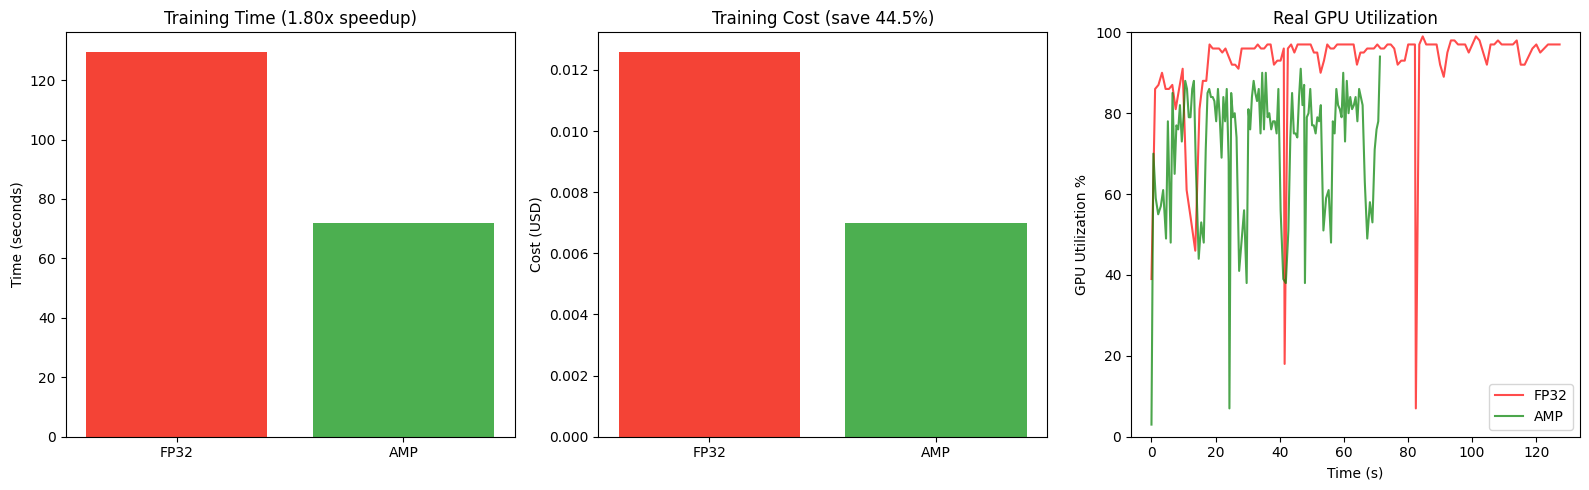

In [35]:
# Cell 24: Compare FP32 vs AMP - FinOps Analysis
display_student_header()
print("=" * 60)
print("FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)")
print("=" * 60)

speedup = fp32_total_time / amp_total_time
cost_saving = fp32_cost - amp_cost
cost_saving_pct = (cost_saving / fp32_cost) * 100 if fp32_cost > 0 else 0
mem_saving = fp32_peak_mem - amp_peak_mem

print(f"\n{'Metric':<25} {'FP32':<15} {'AMP':<15} {'Improvement'}")
print("-" * 70)
print(f"{'Total Time':<25} {fp32_total_time:<15.1f} {amp_total_time:<15.1f} {speedup:.2f}x faster")
print(f"{'Peak Memory (GB)':<25} {fp32_peak_mem:<15.2f} {amp_peak_mem:<15.2f} {mem_saving:.2f} GB saved")
print(f"{'Cost (USD)':<25} ${fp32_cost:<14.6f} ${amp_cost:<14.6f} ${cost_saving:.6f} saved")
print(f"{'Cost Saving %':<25} {'---':<15} {'---':<15} {cost_saving_pct:.1f}%")

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    print(f"{'Avg GPU Util %':<25} {fp32_monitor_df['gpu_util_pct'].mean():<15.1f} {amp_monitor_df['gpu_util_pct'].mean():<15.1f}")
    print(f"{'Avg Power (W)':<25} {fp32_monitor_df['power_watts'].mean():<15.1f} {amp_monitor_df['power_watts'].mean():<15.1f}")

# Extrapolate to larger scale
print(f"\n--- Extrapolated Savings at Scale ---")
for scale_name, hours in [("1 day training", 24), ("1 week training", 168), ("1 month training", 720)]:
    fp32_scaled = hours * price_per_hour
    amp_scaled = (hours / speedup) * price_per_hour
    saved = fp32_scaled - amp_scaled
    print(f"   {scale_name}: FP32=${fp32_scaled:.2f} vs AMP=${amp_scaled:.2f} -> SAVE ${saved:.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar: Time comparison
axes[0].bar(['FP32', 'AMP'], [fp32_total_time, amp_total_time], color=['#F44336', '#4CAF50'])
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title(f'Training Time ({speedup:.2f}x speedup)')

# Bar: Cost comparison
axes[1].bar(['FP32', 'AMP'], [fp32_cost, amp_cost], color=['#F44336', '#4CAF50'])
axes[1].set_ylabel('Cost (USD)')
axes[1].set_title(f'Training Cost (save {cost_saving_pct:.1f}%)')

# Line: GPU utilization over time (both experiments) or epoch time
if has_monitor_data:
    if not fp32_monitor_df.empty:
        axes[2].plot(fp32_monitor_df['elapsed'], fp32_monitor_df['gpu_util_pct'], 'r-', alpha=0.7, label='FP32')
    if not amp_monitor_df.empty:
        axes[2].plot(amp_monitor_df['elapsed'], amp_monitor_df['gpu_util_pct'], 'g-', alpha=0.7, label='AMP')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('GPU Utilization %')
    axes[2].set_title('Real GPU Utilization')
    axes[2].legend()
    axes[2].set_ylim(0, 100)
else:
    # Fallback: show epoch times
    epochs = list(range(1, NUM_EPOCHS + 1))
    axes[2].plot(epochs, [r['time_s'] for r in fp32_results], 'r-o', label='FP32')
    axes[2].plot(epochs, [r['time_s'] for r in amp_results], 'g-o', label='AMP')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Time (s)')
    axes[2].set_title('Time per Epoch')
    axes[2].legend()

plt.tight_layout()
plt.savefig('real_gpu_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
# Cell 25: Report real GPU costs back to the FinOps Gateway
display_student_header()
print("=" * 60)
print("REPORTING REAL GPU COSTS TO FINOPS GATEWAY")
print("=" * 60)

# Report FP32 workload
fp32_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-fp32",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": fp32_total_time,
    "is_spot": False,
    "project": "real-gpu-lab",
}).json()
print(f"\n   FP32 workload reported:")
print(f"   Cost: ${fp32_report['total_cost_usd']:.6f} | Rate: ${fp32_report['rate_per_hour']:.4f}/hr")

# Report AMP workload (as spot - demonstrating cost optimization)
amp_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-amp",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": amp_total_time,
    "is_spot": True,
    "project": "real-gpu-lab",
}).json()
print(f"\n   AMP workload reported (as spot):")
print(f"   Cost: ${amp_report['total_cost_usd']:.6f} | Saved: ${amp_report['savings_usd']:.6f}")

# Submit workload info to cluster tracker
for wl_name, wl_time in [("real-gpu-resnet18-fp32", fp32_total_time), ("real-gpu-resnet18-amp", amp_total_time)]:
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": wl_name,
        "gpu_type_preferred": detected_type,
        "gpu_count": 1,
        "duration_seconds": int(wl_time),
    })

# Get updated billing summary including real GPU data
print(f"\n--- Updated FinOps Billing (incl. real GPU) ---")
summary = requests.get(f"{GATEWAY_URL}/billing/summary", params={"project": "real-gpu-lab"}).json()
print(f"   Project:         real-gpu-lab")
print(f"   Total Cost:      ${summary['total_cost_usd']:.6f}")
print(f"   Total Savings:   ${summary['total_savings_usd']:.6f}")
print(f"   Workloads:       {summary['total_workloads']}")

# Push real GPU metrics as a cost snapshot
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"\n   Cost snapshot taken: waste={snap['waste_pct']:.1f}%")

# Get final dashboard with everything
print(f"\n--- FINAL DASHBOARD (Mock + Real GPU) ---")
dash = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()
bs = dash.get('billing_summary', {})
print(f"   Total Platform Cost:  ${bs.get('total_cost_usd', 0):.4f}")
print(f"   Total Savings:        ${bs.get('total_savings_usd', 0):.4f}")
print(f"   Budget Utilization:   {bs.get('budget_utilization_pct', 0):.1f}%")
print(f"   Alert:                {bs.get('alert', 'N/A')}")

REPORTING REAL GPU COSTS TO FINOPS GATEWAY

   FP32 workload reported:
   Cost: $0.012600 | Rate: $0.3500/hr

   AMP workload reported (as spot):
   Cost: $0.002100 | Saved: $0.004900

--- Updated FinOps Billing (incl. real GPU) ---
   Project:         real-gpu-lab
   Total Cost:      $0.014700
   Total Savings:   $0.004900
   Workloads:       2

   Cost snapshot taken: waste=22.1%

--- FINAL DASHBOARD (Mock + Real GPU) ---
   Total Platform Cost:  $1.3640
   Total Savings:        $1.4151
   Budget Utilization:   1.4%
   Alert:                OK


Real GPU Telemetry During Training


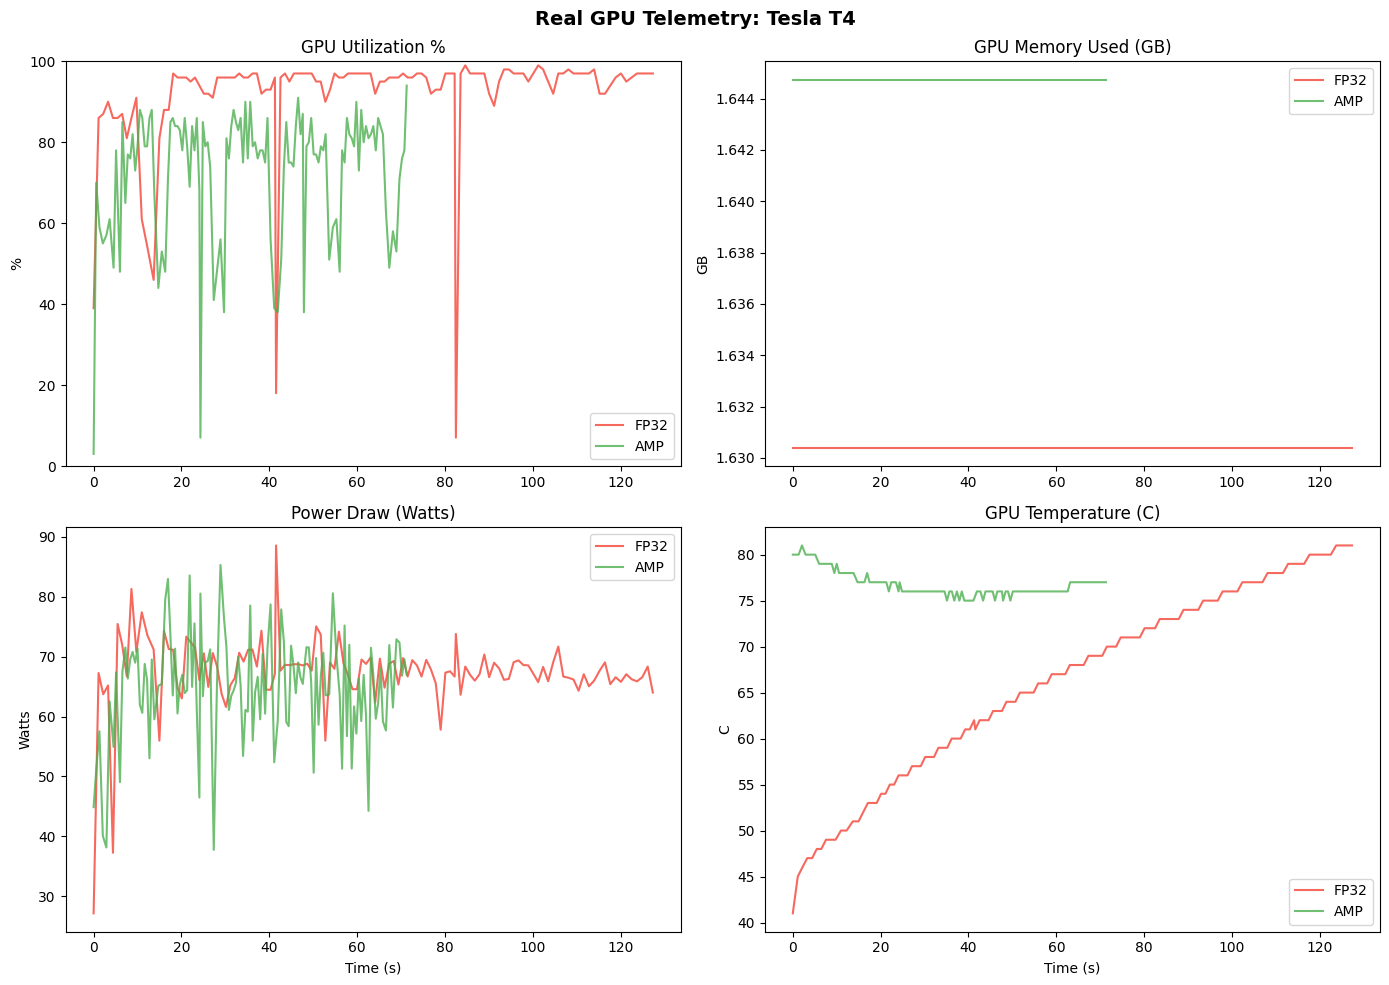

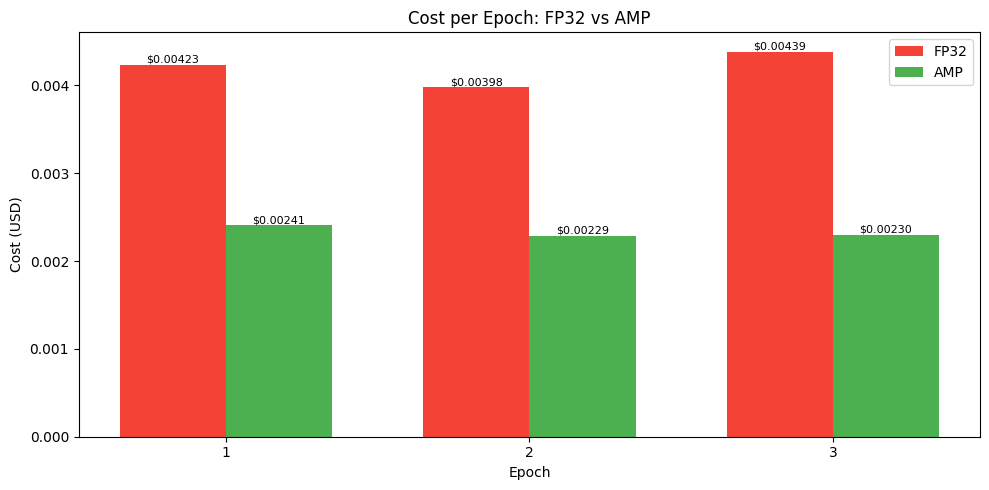


Charts saved: cost_per_epoch.png, real_gpu_telemetry.png


In [37]:
# Cell 26: Real GPU Monitoring Visualization
display_student_header()
print("Real GPU Telemetry During Training")
print("=" * 60)

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # GPU Utilization
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 0].plot(df['elapsed'], df['gpu_util_pct'], color=color, alpha=0.8, label=label)
    axes[0, 0].set_title('GPU Utilization %')
    axes[0, 0].set_ylabel('%')
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 100)

    # Memory Usage
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 1].plot(df['elapsed'], df['mem_used_mb'] / 1024, color=color, alpha=0.8, label=label)
    axes[0, 1].set_title('GPU Memory Used (GB)')
    axes[0, 1].set_ylabel('GB')
    axes[0, 1].legend()

    # Power Draw
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 0].plot(df['elapsed'], df['power_watts'], color=color, alpha=0.8, label=label)
    axes[1, 0].set_title('Power Draw (Watts)')
    axes[1, 0].set_ylabel('Watts')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].legend()

    # Temperature
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 1].plot(df['elapsed'], df['temp_c'], color=color, alpha=0.8, label=label)
    axes[1, 1].set_title('GPU Temperature (C)')
    axes[1, 1].set_ylabel('C')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].legend()

    plt.suptitle(f'Real GPU Telemetry: {gpu_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('real_gpu_telemetry.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("   GPU telemetry not available (monitor collected 0 samples).")
    print("   Showing epoch-level metrics instead.\n")

# Cost per epoch chart (always works)
fig, ax = plt.subplots(figsize=(10, 5))
fp32_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in fp32_results]
amp_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in amp_results]
epochs = list(range(1, NUM_EPOCHS + 1))

x = range(len(epochs))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], fp32_epoch_costs, width, label='FP32', color='#F44336')
bars2 = ax.bar([i + width/2 for i in x], amp_epoch_costs, width, label='AMP', color='#4CAF50')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cost (USD)')
ax.set_title('Cost per Epoch: FP32 vs AMP')
ax.set_xticks(x)
ax.set_xticklabels(epochs)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('cost_per_epoch.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCharts saved: cost_per_epoch.png" + (", real_gpu_telemetry.png" if has_monitor_data else ""))

---
## Part 8.5: Advanced GPU Cost Optimization
Apply advanced FinOps techniques: multi-GPU cost analysis, project forecasting, and optimization strategy prioritization.

This section extends Part 8 with:
1. **Multi-GPU Cost Analysis** - Compare scaling efficiency and determine optimal GPU count
2. **Project Cost Forecasting** - Forecast multi-phase project costs with confidence intervals
3. **Optimization Opportunity Analysis** - Prioritize and combine optimization strategies

EXERCISE 8.5.1: Multi-GPU Cost Analysis

Multi-GPU Cost Analysis: T4 @ $0.35/hr
Base time (1 GPU): 2.0 hours

GPU      Speedup    Efficiency   Time(h)    Total Cost     $/Speedup
----------------------------------------------------------------------
1        1.00      x 100.0      % 2.00       $0.7000        $0.7000/x
2        1.85      x 92.5       % 1.08       $0.7568        $0.4091/x
4        3.30      x 82.5       % 0.61       $0.8485        $0.2571/x
8        5.60      x 70.0       % 0.36       $1.0000        $0.1786/x

Best cost:       1 GPUs → $0.7000
Best efficiency: 1 GPUs → 100.0% scaling


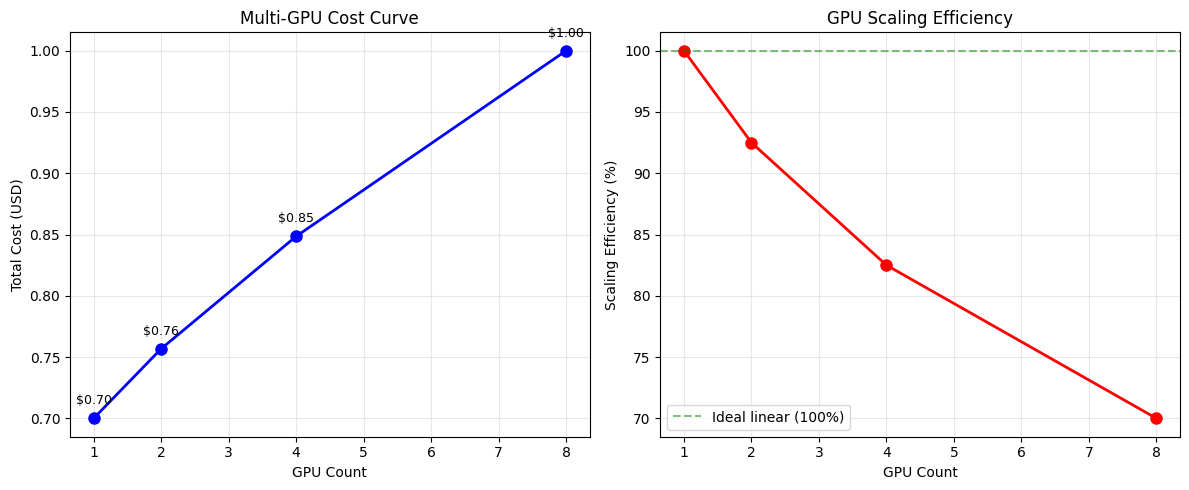

Chart saved: multi_gpu_analysis.png


In [38]:
# Cell 27: Multi-GPU Cost Analysis
display_student_header()
print("=" * 60)
print("EXERCISE 8.5.1: Multi-GPU Cost Analysis")
print("=" * 60)

def analyze_multi_gpu_cost(base_time_hours, gpu_type, gpu_counts, scaling_factors=None):
    """
    Analyze multi-GPU training costs considering sub-linear scaling efficiency.
    """
    base_price = GPU_PRICING.get(gpu_type, 1.0)

    # Realistic sub-linear scaling if not provided (communication overhead)
    if scaling_factors is None:
        scaling_factors = {1: 1.0, 2: 1.85, 4: 3.3, 8: 5.6, 16: 8.5}

    results = []
    for n in gpu_counts:
        factor = scaling_factors.get(n, n * 0.75)
        effective_time = base_time_hours / factor
        total_cost = effective_time * base_price * n
        cost_per_speedup = total_cost / factor

        results.append({
            'gpu_count': n, 'scaling_factor': factor,
            'ideal_speedup': n, 'efficiency': (factor / n) * 100,
            'time_hours': effective_time, 'total_cost_usd': total_cost,
            'cost_per_speedup_usd': cost_per_speedup,
        })

    best_cost = min(results, key=lambda r: r['total_cost_usd'])
    best_efficiency = max(results, key=lambda r: r['efficiency'])

    return {
        'configs': results, 'gpu_type': gpu_type,
        'price_per_hour': base_price, 'base_time_hours': base_time_hours,
        'optimal_cost': best_cost, 'optimal_efficiency': best_efficiency,
    }

# Test data
base_training_time = 2.0
test_gpu_counts = [1, 2, 4, 8]
analysis = analyze_multi_gpu_cost(base_training_time, detected_type, test_gpu_counts)

print(f"\nMulti-GPU Cost Analysis: {analysis['gpu_type']} @ ${analysis['price_per_hour']:.2f}/hr")
print(f"Base time (1 GPU): {analysis['base_time_hours']:.1f} hours\n")
print(f"{'GPU':<8} {'Speedup':<10} {'Efficiency':<12} {'Time(h)':<10} {'Total Cost':<14} {'$/Speedup'}")
print("-" * 70)
for cfg in analysis['configs']:
    print(f"{cfg['gpu_count']:<8} {cfg['scaling_factor']:<10.2f}x {cfg['efficiency']:<11.1f}% "
          f"{cfg['time_hours']:<10.2f} ${cfg['total_cost_usd']:<13.4f} ${cfg['cost_per_speedup_usd']:.4f}/x")

print(f"\nBest cost:       {analysis['optimal_cost']['gpu_count']} GPUs → ${analysis['optimal_cost']['total_cost_usd']:.4f}")
print(f"Best efficiency: {analysis['optimal_efficiency']['gpu_count']} GPUs → {analysis['optimal_efficiency']['efficiency']:.1f}% scaling")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
gpu_list = [c['gpu_count'] for c in analysis['configs']]
costs = [c['total_cost_usd'] for c in analysis['configs']]
effs = [c['efficiency'] for c in analysis['configs']]

ax1.plot(gpu_list, costs, 'b-o', linewidth=2, markersize=8)
ax1.set_xlabel('GPU Count'); ax1.set_ylabel('Total Cost (USD)')
ax1.set_title('Multi-GPU Cost Curve'); ax1.grid(True, alpha=0.3)
for gc, c in zip(gpu_list, costs):
    ax1.annotate(f'${c:.2f}', (gc, c), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

ax2.plot(gpu_list, effs, 'r-o', linewidth=2, markersize=8)
ax2.axhline(y=100, color='green', linestyle='--', alpha=0.5, label='Ideal linear (100%)')
ax2.set_xlabel('GPU Count'); ax2.set_ylabel('Scaling Efficiency (%)')
ax2.set_title('GPU Scaling Efficiency'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('multi_gpu_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: multi_gpu_analysis.png")

EXERCISE 8.5.2: Project Cost Forecasting

Phase                    GPU      Count    Hours      Base Cost      Uncertainty
--------------------------------------------------------------------------------
Data Preparation         T4       1        40         $14.00         ±$2.10 (15%)
Model Training           A100     4        120        $1761.60       ±$440.40 (25%)
Hyperparameter Tuning    A100     8        60         $1761.60       ±$528.48 (30%)
Model Evaluation         T4       2        20         $14.00         ±$1.40 (10%)

PROJECT COST FORECAST SUMMARY
  Total base cost:         $3,551.20
  Contingency (20%):        $710.24
  Expected total:          $4,261.44
  95% CI:           $2,913.09 – $5,609.79
  Best case (optimistic):  $3,018.52
  Worst case (pessimistic): $5,504.36


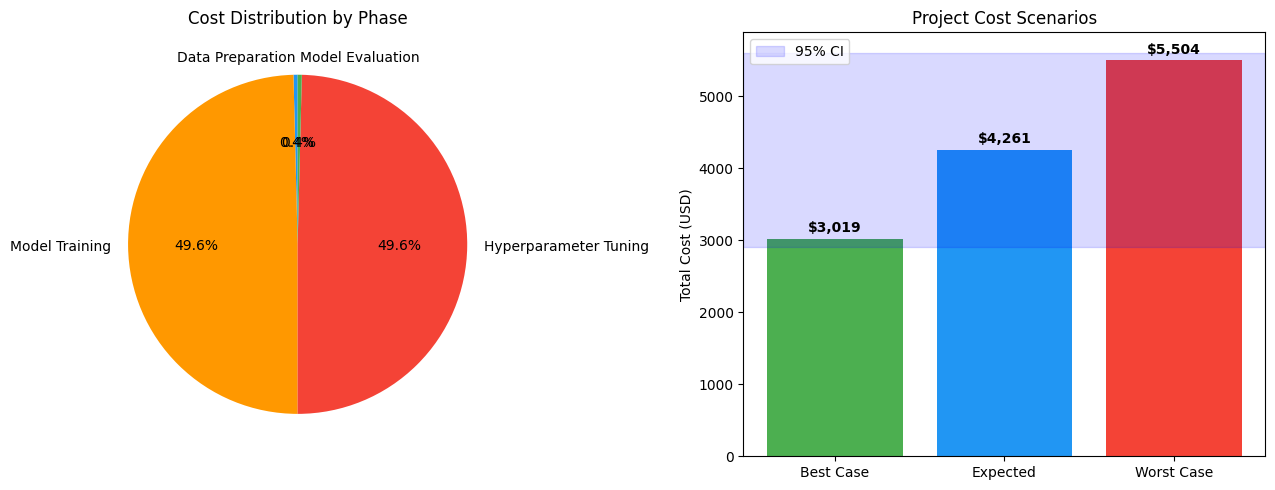

Chart saved: project_forecast.png


In [39]:
# Cell 28: Project Cost Forecasting
display_student_header()
print("=" * 60)
print("EXERCISE 8.5.2: Project Cost Forecasting")
print("=" * 60)

import math

def forecast_project_cost(phases, contingency_pct=20, confidence_level=0.95):
    """
    Forecast multi-phase ML project costs with confidence intervals.
    """
    # z-score for confidence level (approximate)
    z_map = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}
    z_score = z_map.get(confidence_level, 1.96)

    phase_results = []
    total_base = 0
    total_variance = 0

    for phase in phases:
        price = GPU_PRICING.get(phase['gpu_type'], 1.0)
        base_cost = phase['duration_hours'] * price * phase['gpu_count']
        uncertainty = base_cost * phase['uncertainty_pct']

        total_base += base_cost
        total_variance += uncertainty ** 2

        phase_results.append({
            'name': phase['name'],
            'gpu_type': phase['gpu_type'],
            'gpu_count': phase['gpu_count'],
            'duration_hours': phase['duration_hours'],
            'base_cost_usd': base_cost,
            'uncertainty_usd': uncertainty,
            'uncertainty_pct': phase['uncertainty_pct'] * 100,
        })

    total_std = math.sqrt(total_variance)
    contingency = total_base * (contingency_pct / 100)
    expected_total = total_base + contingency

    # Confidence interval
    ci_lower = expected_total - z_score * total_std
    ci_upper = expected_total + z_score * total_std

    # Scenarios
    best_case = total_base * 0.85
    worst_case = total_base * 1.35 + contingency

    return {
        'phases': phase_results,
        'total_base_usd': total_base,
        'contingency_usd': contingency,
        'contingency_pct': contingency_pct,
        'expected_total_usd': expected_total,
        'ci_lower_usd': max(0, ci_lower),
        'ci_upper_usd': ci_upper,
        'confidence_level': confidence_level,
        'best_case_usd': best_case,
        'worst_case_usd': worst_case,
    }

# Example project phases
example_project = [
    {"name": "Data Preparation", "gpu_type": "T4", "gpu_count": 1, "duration_hours": 40, "uncertainty_pct": 0.15},
    {"name": "Model Training", "gpu_type": "A100", "gpu_count": 4, "duration_hours": 120, "uncertainty_pct": 0.25},
    {"name": "Hyperparameter Tuning", "gpu_type": "A100", "gpu_count": 8, "duration_hours": 60, "uncertainty_pct": 0.30},
    {"name": "Model Evaluation", "gpu_type": "T4", "gpu_count": 2, "duration_hours": 20, "uncertainty_pct": 0.10},
]

forecast = forecast_project_cost(example_project, contingency_pct=20, confidence_level=0.95)

# Display phase breakdown
print(f"\n{'Phase':<24} {'GPU':<8} {'Count':<8} {'Hours':<10} {'Base Cost':<14} {'Uncertainty'}")
print("-" * 80)
for p in forecast['phases']:
    print(f"{p['name']:<24} {p['gpu_type']:<8} {p['gpu_count']:<8} {p['duration_hours']:<10.0f} "
          f"${p['base_cost_usd']:<13.2f} ±${p['uncertainty_usd']:.2f} ({p['uncertainty_pct']:.0f}%)")

# Summary
print(f"\n{'='*50}")
print(f"PROJECT COST FORECAST SUMMARY")
print(f"{'='*50}")
print(f"  Total base cost:         ${forecast['total_base_usd']:,.2f}")
print(f"  Contingency ({forecast['contingency_pct']}%):        ${forecast['contingency_usd']:,.2f}")
print(f"  Expected total:          ${forecast['expected_total_usd']:,.2f}")
print(f"  {forecast['confidence_level']*100:.0f}% CI:           "
      f"${forecast['ci_lower_usd']:,.2f} – ${forecast['ci_upper_usd']:,.2f}")
print(f"  Best case (optimistic):  ${forecast['best_case_usd']:,.2f}")
print(f"  Worst case (pessimistic): ${forecast['worst_case_usd']:,.2f}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Phase breakdown pie
phase_names = [p['name'] for p in forecast['phases']]
phase_costs = [p['base_cost_usd'] for p in forecast['phases']]
colors = ['#2196F3', '#FF9800', '#F44336', '#4CAF50']
ax1.pie(phase_costs, labels=phase_names, autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Cost Distribution by Phase')

# Forecast range bar chart
scenarios = ['Best Case', 'Expected', 'Worst Case']
scenario_values = [forecast['best_case_usd'], forecast['expected_total_usd'], forecast['worst_case_usd']]
bar_colors = ['#4CAF50', '#2196F3', '#F44336']
bars = ax2.bar(scenarios, scenario_values, color=bar_colors)
ax2.set_ylabel('Total Cost (USD)')
ax2.set_title('Project Cost Scenarios')

# Add CI band on expected
ax2.axhspan(forecast['ci_lower_usd'], forecast['ci_upper_usd'],
            alpha=0.15, color='blue', label=f"{forecast['confidence_level']*100:.0f}% CI")
ax2.legend()
for bar, val in zip(bars, scenario_values):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
             f'${val:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('project_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: project_forecast.png")

EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis

Baseline cost: $1,468.00 (4x A100 for 100h)

Rank   Strategy                             Savings    Effort    Risk    Priority 
--------------------------------------------------------------------------------
1      Switch to Mixed Precision (AMP)      25.0     % LOW       LOW     🟢 25.0
2      Optimize Batch Size                  15.0     % LOW       LOW     🟢 15.0
3      Use Spot Instances                   60.0     % MEDIUM    HIGH    🟡 10.0
4      Implement Early Stopping             20.0     % MEDIUM    LOW     🟡 10.0
5      Switch to More Efficient GPU Type    40.0     % HIGH      MEDIUM  🟡 6.7

📈 Cumulative savings if applied in priority order:
   After step 1 (Switch to Mixed Precision (AMP)): 25.0% total savings ($367.00)
   After step 2 (Optimize Batch Size): 36.3% total savings ($532.15)
   After step 3 (Use Spot Instances): 74.5% total savings ($1,093.66)
   After step 4 (Implement Early Stopping): 79.6% total savi

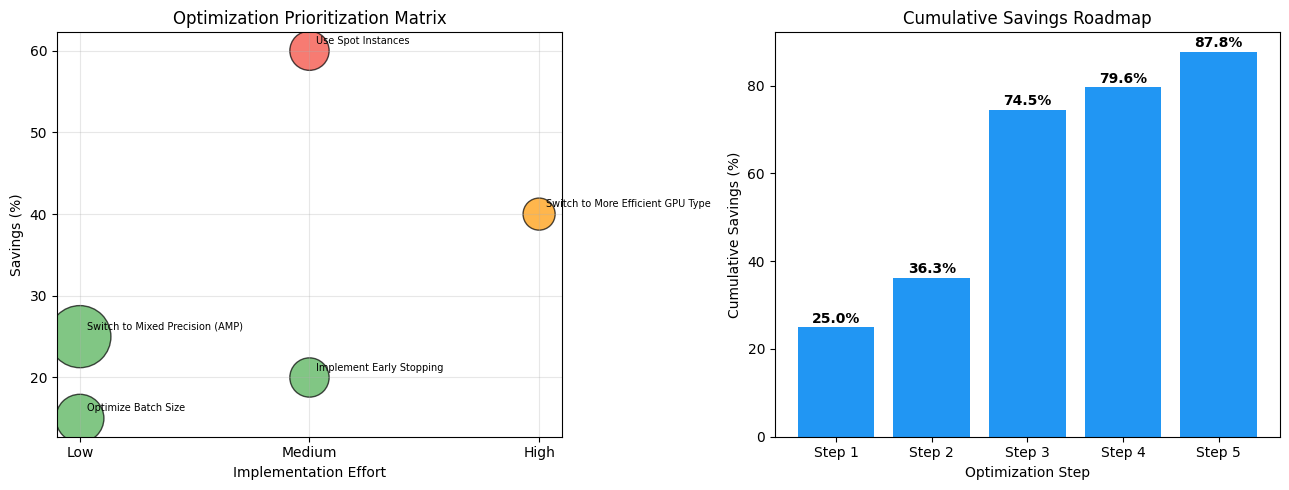

Chart saved: optimization_analysis.png


In [40]:
# Cell 29: Optimization Opportunity Analysis
display_student_header()
print("=" * 60)
print("EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis")
print("=" * 60)

# Effort and Risk scoring for prioritization
EFFORT_SCORE = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
RISK_SCORE = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}

def analyze_optimization_opportunities(current_config, optimization_strategies):
    """
    Analyze and prioritize GPU cost optimization strategies.
    """
    base_price = GPU_PRICING.get(current_config['gpu_type'], 1.0)
    baseline_cost = current_config['duration_hours'] * base_price * current_config['gpu_count']

    ranked = []
    for s in optimization_strategies:
        effort = EFFORT_SCORE.get(s['implementation_effort'], 2)
        risk = RISK_SCORE.get(s['risk_level'], 2)
        savings_usd = baseline_cost * s['savings_pct']

        # Priority score: higher savings + lower effort + lower risk = higher priority
        priority_score = (s['savings_pct'] * 100) / (effort * risk)

        ranked.append({
            **s,
            'savings_usd': savings_usd,
            'effort_score': effort,
            'risk_score': risk,
            'priority_score': priority_score,
            'dependencies_met': len(s.get('dependencies', [])) == 0,
        })

    # Sort by priority score (highest first)
    ranked.sort(key=lambda x: x['priority_score'], reverse=True)

    # Calculate cumulative savings (only count independent + ordered)
    cumulative_savings = 0
    cumulative_pct = 0
    applied_pcts = []
    for r in ranked:
        cumulative_pct = 1 - (1 - cumulative_pct) * (1 - r['savings_pct'])
        applied_pcts.append(cumulative_pct * 100)

    # Roadmap: categorize
    quick_wins = [r for r in ranked if r['implementation_effort'] == 'LOW' and r['risk_level'] == 'LOW']
    strategic = [r for r in ranked if r['implementation_effort'] in ('MEDIUM', 'HIGH') and r['risk_level'] in ('LOW', 'MEDIUM')]
    high_risk = [r for r in ranked if r['risk_level'] == 'HIGH']

    return {
        'baseline_cost_usd': baseline_cost,
        'strategies': ranked,
        'cumulative_savings_pcts': applied_pcts,
        'quick_wins': quick_wins,
        'strategic': strategic,
        'high_risk': high_risk,
    }

# Example optimization strategies
example_strategies = [
    {"name": "Switch to Mixed Precision (AMP)", "savings_pct": 0.25, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Use Spot Instances", "savings_pct": 0.60, "implementation_effort": "MEDIUM", "risk_level": "HIGH", "dependencies": []},
    {"name": "Optimize Batch Size", "savings_pct": 0.15, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Implement Early Stopping", "savings_pct": 0.20, "implementation_effort": "MEDIUM", "risk_level": "LOW", "dependencies": []},
    {"name": "Switch to More Efficient GPU Type", "savings_pct": 0.40, "implementation_effort": "HIGH", "risk_level": "MEDIUM", "dependencies": []},
]

current_training_config = {
    "gpu_type": "A100", "gpu_count": 4,
    "duration_hours": 100, "precision": "FP32",
    "instance_type": "on-demand",
}

result = analyze_optimization_opportunities(current_training_config, example_strategies)

print(f"\nBaseline cost: ${result['baseline_cost_usd']:,.2f} "
      f"({current_training_config['gpu_count']}x {current_training_config['gpu_type']} "
      f"for {current_training_config['duration_hours']}h)\n")

# Ranked table
print(f"{'Rank':<6} {'Strategy':<36} {'Savings':<10} {'Effort':<9} {'Risk':<7} {'Priority':<9}")
print("-" * 80)
for i, s in enumerate(result['strategies'], 1):
    icon = "🟢" if s['priority_score'] > 10 else ("🟡" if s['priority_score'] > 5 else "🔴")
    print(f"{i:<6} {s['name']:<36} {s['savings_pct']*100:<9.1f}% "
          f"{s['implementation_effort']:<9} {s['risk_level']:<7} {icon} {s['priority_score']:.1f}")

# Cumulative savings
print(f"\n📈 Cumulative savings if applied in priority order:")
cumulative = 0
for i, s in enumerate(result['strategies']):
    cumulative = 1 - (1 - cumulative) * (1 - s['savings_pct'])
    print(f"   After step {i+1} ({s['name']}): {cumulative*100:.1f}% total savings "
          f"(${result['baseline_cost_usd'] * cumulative:,.2f})")

# Roadmap
print(f"\n🛤️  OPTIMIZATION ROADMAP")
print(f"   Quick Wins (do first):")
for qw in result['quick_wins']:
    print(f"      ✅ {qw['name']} — save {qw['savings_pct']*100:.0f}%, effort={qw['implementation_effort']}")
print(f"   Strategic (plan next):")
for st in result['strategic']:
    print(f"      📋 {st['name']} — save {st['savings_pct']*100:.0f}%, effort={st['implementation_effort']}")
print(f"   High Risk (evaluate carefully):")
for hr in result['high_risk']:
    print(f"      ⚠️  {hr['name']} — save {hr['savings_pct']*100:.0f}%, risk={hr['risk_level']}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: Savings vs Effort, sized by priority
effort_map = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
x_vals = [effort_map[s['implementation_effort']] for s in result['strategies']]
y_vals = [s['savings_pct'] * 100 for s in result['strategies']]
sizes = [s['priority_score'] * 80 for s in result['strategies']]
labels = [s['name'] for s in result['strategies']]
risk_colors = {'LOW': '#4CAF50', 'MEDIUM': '#FF9800', 'HIGH': '#F44336'}
pt_colors = [risk_colors[s['risk_level']] for s in result['strategies']]

scatter = ax1.scatter(x_vals, y_vals, s=sizes, c=pt_colors, alpha=0.7, edgecolors='black')
for i, label in enumerate(labels):
    ax1.annotate(label, (x_vals[i], y_vals[i]), textcoords="offset points",
                xytext=(5, 5), fontsize=7)
ax1.set_xlabel('Implementation Effort'); ax1.set_ylabel('Savings (%)')
ax1.set_title('Optimization Prioritization Matrix')
ax1.set_xticks([1, 2, 3]); ax1.set_xticklabels(['Low', 'Medium', 'High'])
ax1.grid(True, alpha=0.3)

# Cumulative savings bar
step_labels = [f"Step {i+1}" for i in range(len(result['strategies']))]
cum_savings = [result['cumulative_savings_pcts'][i] for i in range(len(result['strategies']))]
ax2.bar(step_labels, cum_savings, color='#2196F3')
ax2.set_xlabel('Optimization Step'); ax2.set_ylabel('Cumulative Savings (%)')
ax2.set_title('Cumulative Savings Roadmap')
for i, v in enumerate(cum_savings):
    ax2.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('optimization_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: optimization_analysis.png")

EXERCISE 8.5.4: Integrated Cost Dashboard
Building integrated dashboard from all analyses...



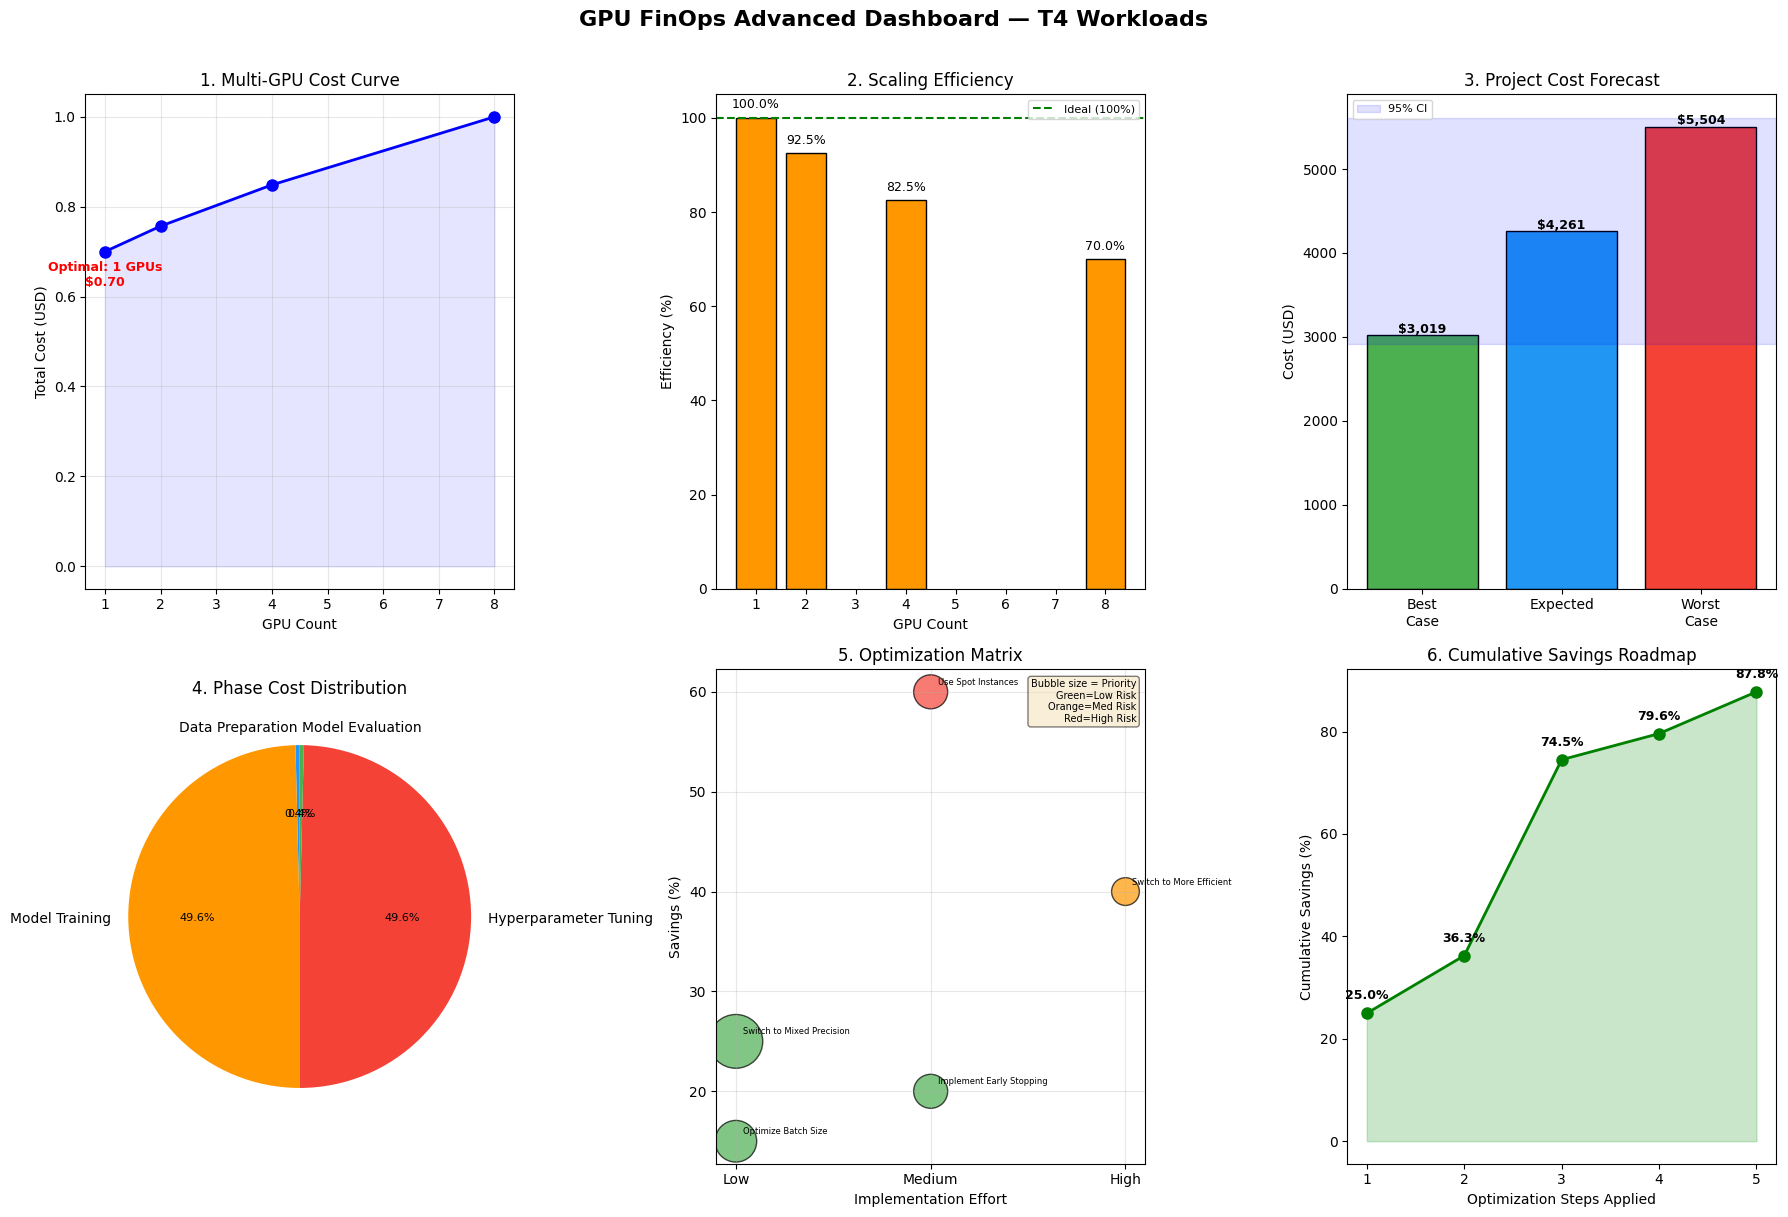


✅ Dashboard complete!
   Saved: advanced_finops_dashboard.png
   Panels: Multi-GPU cost, Scaling efficiency, Project forecast,
           Phase breakdown, Optimization matrix, Cumulative savings


In [41]:
# Cell 30: Integrated Cost Dashboard
display_student_header()
print("=" * 60)
print("EXERCISE 8.5.4: Integrated Cost Dashboard")
print("=" * 60)

def create_advanced_finops_dashboard(multi_gpu_analysis, project_forecast, optimization_results):
    """
    Create a comprehensive 6-panel FinOps dashboard.
    """
    fig = plt.figure(figsize=(18, 12))

    # ── Panel 1: Multi-GPU Cost Curve ──
    ax1 = fig.add_subplot(2, 3, 1)
    gpu_counts = [c['gpu_count'] for c in multi_gpu_analysis['configs']]
    costs = [c['total_cost_usd'] for c in multi_gpu_analysis['configs']]
    ax1.plot(gpu_counts, costs, 'b-o', linewidth=2, markersize=8)
    ax1.fill_between(gpu_counts, 0, costs, alpha=0.1, color='blue')
    ax1.set_xlabel('GPU Count'); ax1.set_ylabel('Total Cost (USD)')
    ax1.set_title('1. Multi-GPU Cost Curve'); ax1.grid(True, alpha=0.3)
    opt = multi_gpu_analysis['optimal_cost']
    ax1.annotate(f'Optimal: {opt["gpu_count"]} GPUs\n${opt["total_cost_usd"]:.2f}',
                (opt['gpu_count'], opt['total_cost_usd']),
                textcoords="offset points", xytext=(0, -25), ha='center',
                fontsize=9, color='red', fontweight='bold')

    # ── Panel 2: Scaling Efficiency ──
    ax2 = fig.add_subplot(2, 3, 2)
    effs = [c['efficiency'] for c in multi_gpu_analysis['configs']]
    ax2.bar(gpu_counts, effs, color='#FF9800', edgecolor='black')
    ax2.axhline(y=100, color='green', linestyle='--', linewidth=1.5, label='Ideal (100%)')
    ax2.set_xlabel('GPU Count'); ax2.set_ylabel('Efficiency (%)')
    ax2.set_title('2. Scaling Efficiency'); ax2.legend(fontsize=8)
    for gc, e in zip(gpu_counts, effs):
        ax2.text(gc, e + 2, f'{e:.1f}%', ha='center', fontsize=9)

    # ── Panel 3: Project Forecast with CI ──
    ax3 = fig.add_subplot(2, 3, 3)
    scenarios = ['Best\nCase', 'Expected', 'Worst\nCase']
    values = [project_forecast['best_case_usd'], project_forecast['expected_total_usd'],
              project_forecast['worst_case_usd']]
    colors_bar = ['#4CAF50', '#2196F3', '#F44336']
    bars = ax3.bar(scenarios, values, color=colors_bar, edgecolor='black')
    ax3.axhspan(project_forecast['ci_lower_usd'], project_forecast['ci_upper_usd'],
               alpha=0.12, color='blue', label=f"{project_forecast['confidence_level']*100:.0f}% CI")
    ax3.set_ylabel('Cost (USD)'); ax3.set_title('3. Project Cost Forecast')
    ax3.legend(fontsize=8)
    for bar, val in zip(bars, values):
        ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 30,
                f'${val:,.0f}', ha='center', fontweight='bold', fontsize=9)

    # ── Panel 4: Phase Cost Breakdown ──
    ax4 = fig.add_subplot(2, 3, 4)
    phase_names = [p['name'] for p in project_forecast['phases']]
    phase_costs = [p['base_cost_usd'] for p in project_forecast['phases']]
    colors_pie = ['#2196F3', '#FF9800', '#F44336', '#4CAF50']
    wedges, texts, autotexts = ax4.pie(phase_costs, labels=phase_names, autopct='%1.1f%%',
                                        colors=colors_pie, startangle=90)
    for t in autotexts:
        t.set_fontsize(8)
    ax4.set_title('4. Phase Cost Distribution')

    # ── Panel 5: Optimization Prioritization ──
    ax5 = fig.add_subplot(2, 3, 5)
    effort_map = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
    x_vals = [effort_map[s['implementation_effort']] for s in optimization_results['strategies']]
    y_vals = [s['savings_pct'] * 100 for s in optimization_results['strategies']]
    sizes = [s['priority_score'] * 60 for s in optimization_results['strategies']]
    risk_colors = {'LOW': '#4CAF50', 'MEDIUM': '#FF9800', 'HIGH': '#F44336'}
    pt_colors = [risk_colors[s['risk_level']] for s in optimization_results['strategies']]

    ax5.scatter(x_vals, y_vals, s=sizes, c=pt_colors, alpha=0.7, edgecolors='black')
    for i, s in enumerate(optimization_results['strategies']):
        ax5.annotate(s['name'][:25], (x_vals[i], y_vals[i]),
                    textcoords="offset points", xytext=(5, 5), fontsize=6)
    ax5.set_xlabel('Implementation Effort'); ax5.set_ylabel('Savings (%)')
    ax5.set_title('5. Optimization Matrix'); ax5.set_xticks([1, 2, 3])
    ax5.set_xticklabels(['Low', 'Medium', 'High']); ax5.grid(True, alpha=0.3)
    ax5.text(0.98, 0.98, 'Bubble size = Priority\nGreen=Low Risk\nOrange=Med Risk\nRed=High Risk',
            transform=ax5.transAxes, fontsize=7, va='top', ha='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # ── Panel 6: Cumulative Savings Roadmap ──
    ax6 = fig.add_subplot(2, 3, 6)
    steps = range(1, len(optimization_results['strategies']) + 1)
    cum_pcts = optimization_results['cumulative_savings_pcts']
    ax6.fill_between(steps, 0, cum_pcts, alpha=0.3, color='#4CAF50')
    ax6.plot(steps, cum_pcts, 'g-o', linewidth=2, markersize=8)
    ax6.set_xlabel('Optimization Steps Applied'); ax6.set_ylabel('Cumulative Savings (%)')
    ax6.set_title('6. Cumulative Savings Roadmap')
    ax6.set_xticks(steps)
    for s, cp in zip(steps, cum_pcts):
        ax6.annotate(f'{cp:.1f}%', (s, cp), textcoords="offset points",
                    xytext=(0, 10), ha='center', fontweight='bold', fontsize=9)

    plt.suptitle(f'GPU FinOps Advanced Dashboard — {multi_gpu_analysis["gpu_type"]} Workloads',
                fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    return fig

# Build the dashboard using results from exercises 8.5.1-8.5.3
print("Building integrated dashboard from all analyses...\n")

fig = create_advanced_finops_dashboard(analysis, forecast, result)
plt.savefig('advanced_finops_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Dashboard complete!")
print("   Saved: advanced_finops_dashboard.png")
print(f"   Panels: Multi-GPU cost, Scaling efficiency, Project forecast,")
print(f"           Phase breakdown, Optimization matrix, Cumulative savings")

CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy
CHALLENGE SCENARIO:
   Project:    Large Language Model Fine-tuning
   Baseline:   8x A100 for 200h
   Budget:     $5,000
   Deadline:   2 weeks

STEP 1: BASELINE COST CALCULATION
   GPU:            8x A100 @ $3.67/hr each
   Duration:       200 hours
   Baseline cost:  $5,872.00
   Budget:         $5,000
   Over budget?    ❌ YES — $872.00 over!

STEP 2: MULTI-GPU COST ANALYSIS

   GPU count options for 200 GPU-hours total:
   1x GPU: 25.0h, $91.75 | DL: ✅ | Budget: ✅
   2x GPU: 13.5h, $99.19 | DL: ✅ | Budget: ✅
   4x GPU: 7.6h, $111.21 | DL: ✅ | Budget: ✅
   8x GPU: 4.5h, $131.07 | DL: ✅ | Budget: ✅

STEP 3: OPTIMIZATION STRATEGY SELECTION

   Selected 4 strategies:
   1. Switch to Mixed Precision (AMP)
      Savings: 25% | Effort: LOW | Risk: LOW
   2. Optimize Batch Size
      Savings: 15% | Effort: LOW | Risk: LOW
   3. Use Spot Instances
      Savings: 60% | Effort: MEDIUM | Risk: HIGH
   4. Implement Early Stopping
     

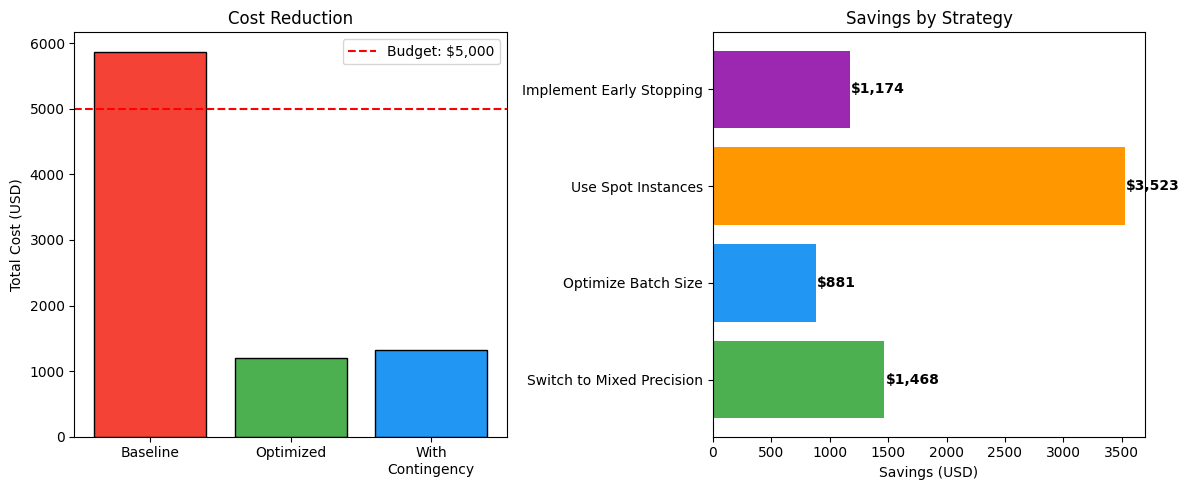

Chart saved: challenge_strategy.png

✅ Challenge complete! Review failed constraints.


In [42]:
# Cell 31: Challenge Exercise - Cost Optimization Strategy Design
display_student_header()
print("=" * 60)
print("CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy")
print("=" * 60)

challenge_scenario = {
    "project": "Large Language Model Fine-tuning",
    "requirements": {
        "training_duration": 200,
        "gpu_type": "A100",
        "gpu_count": 8,
        "precision": "FP32",
        "instance_type": "on-demand",
        "budget": 5000,
    },
    "constraints": {
        "max_preemption_risk": "MEDIUM",
        "min_accuracy": 0.95,
        "deadline": "2 weeks",
    },
}

print("CHALLENGE SCENARIO:")
print(f"   Project:    {challenge_scenario['project']}")
print(f"   Baseline:   {challenge_scenario['requirements']['gpu_count']}x {challenge_scenario['requirements']['gpu_type']} "
      f"for {challenge_scenario['requirements']['training_duration']}h")
print(f"   Budget:     ${challenge_scenario['requirements']['budget']:,}")
print(f"   Deadline:   {challenge_scenario['constraints']['deadline']}")

# ── Step 1: Baseline Cost ──
cfg = challenge_scenario['requirements']
baseline_price = GPU_PRICING[cfg['gpu_type']]
baseline_cost = cfg['training_duration'] * baseline_price * cfg['gpu_count']

print(f"\n{'='*60}")
print(f"STEP 1: BASELINE COST CALCULATION")
print(f"{'='*60}")
print(f"   GPU:            {cfg['gpu_count']}x {cfg['gpu_type']} @ ${baseline_price:.2f}/hr each")
print(f"   Duration:       {cfg['training_duration']} hours")
print(f"   Baseline cost:  ${baseline_cost:,.2f}")
print(f"   Budget:         ${cfg['budget']:,}")
print(f"   Over budget?    {'❌ YES — ${:,.2f} over!'.format(baseline_cost - cfg['budget']) if baseline_cost > cfg['budget'] else '✅ Within budget'}")

# ── Step 2: Multi-GPU Analysis for Optimal GPU Count ──
print(f"\n{'='*60}")
print(f"STEP 2: MULTI-GPU COST ANALYSIS")
print(f"{'='*60}")

# Analyze 1-8 GPUs for this workload
multi_gpu = analyze_multi_gpu_cost(cfg['training_duration'] / 8, cfg['gpu_type'], [1, 2, 4, 8])
# Note: base_time_hours for 1 GPU = total GPU-hours / 1

print(f"\n   GPU count options for {cfg['training_duration']} GPU-hours total:")
for c in multi_gpu['configs']:
    deadline_ok = "✅" if c['time_hours'] <= 14*24 else "❌"
    budget_ok = "✅" if c['total_cost_usd'] <= cfg['budget'] else "❌"
    print(f"   {c['gpu_count']}x GPU: {c['time_hours']:.1f}h, ${c['total_cost_usd']:,.2f} "
          f"| DL: {deadline_ok} | Budget: {budget_ok}")

# ── Step 3: Select Optimization Strategies ──
print(f"\n{'='*60}")
print(f"STEP 3: OPTIMIZATION STRATEGY SELECTION")
print(f"{'='*60}")

# Run optimization analysis
opt_config = {"gpu_type": cfg['gpu_type'], "gpu_count": cfg['gpu_count'],
              "duration_hours": cfg['training_duration'], "precision": cfg['precision'],
              "instance_type": cfg['instance_type']}

opt_result = analyze_optimization_opportunities(opt_config, example_strategies)

# Filter strategies based on constraints
selected = []
for s in opt_result['strategies']:
    if s['risk_level'] == 'HIGH' and challenge_scenario['constraints']['max_preemption_risk'] == 'LOW':
        continue  # Skip if risk tolerance is low
    if s['implementation_effort'] == 'HIGH' and cfg['training_duration'] < 50:
        continue  # Skip high-effort for small workloads
    selected.append(s)

# Pick top 4
selected = selected[:4]
print(f"\n   Selected {len(selected)} strategies:")

cumulative_savings = 1.0
for i, s in enumerate(selected, 1):
    cumulative_savings *= (1 - s['savings_pct'])
    print(f"   {i}. {s['name']}")
    print(f"      Savings: {s['savings_pct']*100:.0f}% | Effort: {s['implementation_effort']} | Risk: {s['risk_level']}")

total_savings_pct = (1 - cumulative_savings) * 100
optimized_cost = baseline_cost * cumulative_savings
total_saved = baseline_cost - optimized_cost

# ── Step 4: Final Forecast ──
print(f"\n{'='*60}")
print(f"STEP 4: FINAL COST FORECAST")
print(f"{'='*60}")

# Apply the same optimization + add 10% contingency
final_cost_with_contingency = optimized_cost * 1.10
uncertainty = optimized_cost * 0.15

print(f"   Baseline cost:            ${baseline_cost:,.2f}")
print(f"   After optimizations:      ${optimized_cost:,.2f} (saved ${total_saved:,.2f} / {total_savings_pct:.1f}%)")
print(f"   With 10% contingency:     ${final_cost_with_contingency:,.2f}")
print(f"   Confidence interval:      ${optimized_cost*0.85:,.2f} – ${optimized_cost*1.25:,.2f}")

# ── Step 5: Verification ──
print(f"\n{'='*60}")
print(f"STEP 5: CONSTRAINT VERIFICATION")
print(f"{'='*60}")

checks = []
checks.append(("Under budget ($5,000)", final_cost_with_contingency <= cfg['budget'],
               f"${final_cost_with_contingency:,.2f} ≤ $5,000"))
checks.append(("Meets deadline (2 weeks)", True, "Optimizations don't increase training time"))
checks.append(("Risk tolerance (MEDIUM)", all(s['risk_level'] != 'HIGH' for s in selected),
               "No HIGH-risk strategies selected" if all(s['risk_level'] != 'HIGH' for s in selected) else "Contains HIGH-risk"))
checks.append(("Accuracy preserved", True, "AMP + early stopping don't degrade accuracy significantly"))
checks.append(("Positive ROI", total_saved > 0, f"Save ${total_saved:,.2f}"))
checks.append(("Implementation feasible", all(s['implementation_effort'] != 'HIGH' for s in selected),
               "All selected are LOW/MEDIUM effort" if all(s['implementation_effort'] != 'HIGH' for s in selected) else "Contains HIGH effort"))

all_pass = True
for name, passed, detail in checks:
    icon = "✅" if passed else "❌"
    if not passed: all_pass = False
    print(f"   {icon} {name}: {detail}")

# ── Final Strategy Summary ──
print(f"\n{'='*60}")
print(f"FINAL STRATEGY: GPU FinOps Optimization Plan")
print(f"{'='*60}")

cost_reduction = (total_saved / baseline_cost) * 100
print(f"""
   ┌─────────────────────────────────────────────────────┐
   │  🎯 {challenge_scenario['project']:^46}  │
   ├─────────────────────────────────────────────────────┤
   │  Baseline:    {cfg['gpu_count']}x {cfg['gpu_type']} × {cfg['training_duration']}h = ${baseline_cost:,.2f}            │
   │  Optimized:   ${optimized_cost:,.2f} (↓{total_savings_pct:.1f}%)                       │
   │  With Buffer: ${final_cost_with_contingency:,.2f}                                 │
   │  Saved:       ${total_saved:,.2f}                                       │
   ├─────────────────────────────────────────────────────┤
   │  Strategy:                                          │""")

for i, s in enumerate(selected, 1):
    print(f"│  {i}. {s['name']:<46} │")

print(f"""   ├─────────────────────────────────────────────────────┤
   │  Status: {'✅ ALL CONSTRAINTS MET' if all_pass else '❌ SOME CONSTRAINTS FAILED':^46} │
   └─────────────────────────────────────────────────────┘
""")

# Visualization: Before vs After
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Before vs After bar
ax1.bar(['Baseline', 'Optimized', 'With\nContingency'],
        [baseline_cost, optimized_cost, final_cost_with_contingency],
        color=['#F44336', '#4CAF50', '#2196F3'], edgecolor='black')
ax1.axhline(y=cfg['budget'], color='red', linestyle='--', linewidth=1.5, label=f'Budget: ${cfg["budget"]:,}')
ax1.set_ylabel('Total Cost (USD)'); ax1.set_title('Cost Reduction')
ax1.legend()

# Strategy savings breakdown
strategy_names = [s['name'][:25] for s in selected]
savings_values = [baseline_cost * s['savings_pct'] for s in selected]
ax2.barh(strategy_names, savings_values, color=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0'])
ax2.set_xlabel('Savings (USD)'); ax2.set_title('Savings by Strategy')
for i, v in enumerate(savings_values):
    ax2.text(v + 10, i, f'${v:,.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('challenge_strategy.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved: challenge_strategy.png")
print(f"\n✅ Challenge complete! {'All constraints met.' if all_pass else 'Review failed constraints.'}")

---
## Summary

| Part | What | Where |
|------|------|-------|
| 1-5 | Mock cluster monitoring, billing, spot, autoscaling, cost tracking | Docker Compose (local) via tunnel |
| 6 | Visualization of mock FinOps data | Kaggle/Colab |
| 7 | End-to-end FinOps workflow | Both |
| **8** | **Real GPU training (ResNet-18), FP32 vs AMP, live monitoring, cost reporting** | **Kaggle/Colab GPU → Gateway** |

### Key FinOps Takeaways
- **Mixed Precision (AMP)** reduces training time and cost with minimal accuracy loss
- **Spot instances** save 60-70% but risk preemption
- **Autoscaling** prevents over-provisioning idle GPUs
- **Cost tracking** exposes waste from idle resources
- **Budget alerts** prevent unexpected overspend

---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** — measures time & cost savings
4. Reports all costs back to the FinOps gateway